# EDA de sepsis

Este notebook prepara un análisis exploratorio inicial de la base `SEPSIS_FINAL`. El flujo sigue este orden:

1. Instalación mínima e imports.
2. Carga y primera inspección de la base.
3. Clasificación de variables usando el metadata y la estructura real del CSV.
4. Análisis univariante por tipo de variable.
5. Estudio de correlación global.
6. Estudio bivariante de relaciones especialmente relevantes.

In [12]:
# Instalacion minima de paquetes
%pip install pandas seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


In [14]:
df = pd.read_csv('bbdd/Supplementary Table 3. SEPSIS_FINAL.csv')

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones: 23706 filas x 51 columnas


,Unnamed: 0,gender,admission_age,ethnicity,admission_type,admission_location,marital_status,unitdischargeoffset,hospitaldischargeoffset,los_icu,los_hospital,hospital_expire_flag,apsiii,apsiii_prob,hr_score,mbp_score,temp_score,resp_rate_score,hematocrit_score,wbc_score,creatinine_score,uo_score,bun_score,sodium_score,glucose_score,gcs_score,heart_rate_max,heart_rate_min,mbp_min,mbp_max,temperature_min,temperature_max,resp_rate_min,resp_rate_max,hematocrit_min,hematocrit_max,wbc_min,wbc_max,creatinine_min,creatinine_max,bun_min,bun_max,sodium_min,sodium_max,glucose_min,glucose_max,urineoutput,gcs_unable,gcs_eyes,gcs_verbal,gcs_motor
0,0,1,48.966011,27,8,8,2,3249,8986,2.26,12.911111,0,40,0.072723,0.0,15.0,0.000000,8.0,3.0,0.0,0.0,5.0,7.0,0.0,0.0,0.0,98.0,76.0,58.5,85.0,36.600000,37.800000,9.0,25.0,26.3,30.4,10.0,13.7,0.7,0.7,19.0,21.0,136.0,136.0,98.0,167.0,1248.0,0.0,3.0,5.0,6.0
1,1,1,64.126857,28,3,6,1,3107,5777,2.16,4.260417,0,24,0.035511,5.0,4.0,0.000000,8.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,118.0,85.0,76.0,112.0,36.110000,38.170000,10.0,24.0,43.3,43.8,7.3,12.7,1.0,1.1,20.0,20.0,142.0,145.0,140.0,163.0,3295.0,0.0,4.0,5.0,6.0
2,2,0,81.929747,28,3,6,2,3461,5980,2.40,4.993750,0,53,0.126616,0.0,7.0,1.024437,6.0,3.0,0.0,4.0,4.0,11.0,0.0,0.0,15.0,81.0,56.0,62.0,105.0,36.237675,37.504809,12.0,26.0,25.0,33.8,12.7,15.4,1.1,1.5,32.0,46.0,139.0,139.0,70.0,190.0,1769.0,0.0,3.0,1.0,6.0
3,4,1,77.496937,28,1,6,1,2064,8799,1.43,6.112500,0,28,0.042586,1.0,15.0,2.000000,0.0,3.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,105.0,70.0,50.0,85.0,35.700000,37.100000,9.0,26.0,29.3,31.4,8.8,9.6,0.6,0.7,15.0,23.0,141.0,141.0,106.0,158.0,3195.0,1.0,1.0,0.0,1.0
4,6,1,66.301944,28,8,8,2,7866,20737,5.46,14.401389,0,38,0.066601,5.0,10.0,0.000000,0.0,3.0,0.0,0.0,7.0,0.0,0.0,0.0,13.0,117.0,76.0,54.0,153.0,36.670000,37.940000,12.0,24.0,29.8,35.5,5.0,10.0,0.7,0.7,11.0,14.0,141.0,142.0,100.0,117.0,650.0,0.0,3.0,4.0,4.0


In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 23706 entries, 0 to 23705
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               23706 non-null  int64  
 1   gender                   23706 non-null  int64  
 2   admission_age            23706 non-null  float64
 3   ethnicity                23706 non-null  int64  
 4   admission_type           23706 non-null  int64  
 5   admission_location       23706 non-null  int64  
 6   marital_status           23706 non-null  int64  
 7   unitdischargeoffset      23706 non-null  int64  
 8   hospitaldischargeoffset  23706 non-null  int64  
 9   los_icu                  23706 non-null  float64
 10  los_hospital             23706 non-null  float64
 11  hospital_expire_flag     23706 non-null  int64  
 12  apsiii                   23706 non-null  int64  
 13  apsiii_prob              23706 non-null  float64
 14  hr_score                 23706 no

## Clasificación de variables

Tomando como referencia el metadata y el contenido real del CSV:

- `Unnamed: 0` actúa como identificador de fila y no se usará en el análisis.
- Las variables como `gender`, `ethnicity`, `admission_type` o `marital_status` son categóricas, aunque en este fichero estén codificadas numéricamente.
- Las variables `gcs_*` y las variables `*_score` son ordinales: expresan niveles o puntuaciones con orden natural.
- Las variables `los_*` y `*offset` son numéricas temporales.
- No hay columnas de tipo fecha/hora en este CSV final.


In [16]:
identifier_vars = ['Unnamed: 0']
categorical_vars = ['gender', 'ethnicity', 'admission_type', 'admission_location', 'marital_status', 'hospital_expire_flag', 'gcs_unable']
ordinal_vars = ['hr_score', 'mbp_score', 'temp_score', 'resp_rate_score', 'hematocrit_score', 'wbc_score', 'creatinine_score', 'uo_score', 'bun_score', 'sodium_score', 'glucose_score', 'gcs_score', 'gcs_eyes', 'gcs_verbal', 'gcs_motor']
temporal_numeric_vars = ['unitdischargeoffset', 'hospitaldischargeoffset', 'los_icu', 'los_hospital']
continuous_vars = ['admission_age', 'apsiii', 'apsiii_prob', 'heart_rate_max', 'heart_rate_min', 'mbp_min', 'mbp_max', 'temperature_min', 'temperature_max', 'resp_rate_min', 'resp_rate_max', 'hematocrit_min', 'hematocrit_max', 'wbc_min', 'wbc_max', 'creatinine_min', 'creatinine_max', 'bun_min', 'bun_max', 'sodium_min', 'sodium_max', 'glucose_min', 'glucose_max', 'urineoutput']
date_vars = []
all_typed_vars = categorical_vars + ordinal_vars + temporal_numeric_vars + continuous_vars + date_vars

tipos_variables = []
for col in identifier_vars:
    tipos_variables.append((col, 'identificador', 'id'))
for col in categorical_vars:
    tipos_variables.append((col, 'categorica', 'nominal codificada'))
for col in ordinal_vars:
    tipos_variables.append((col, 'categorica', 'ordinal'))
for col in temporal_numeric_vars:
    tipos_variables.append((col, 'numerica', 'temporal'))
for col in continuous_vars:
    tipos_variables.append((col, 'numerica', 'continua'))
for col in date_vars:
    tipos_variables.append((col, 'fecha', 'datetime'))

tipos_df = pd.DataFrame(tipos_variables, columns=['variable', 'tipo_general', 'subtipo'])
tipos_df


,variable,tipo_general,subtipo
0,Unnamed: 0,identificador,id
1,gender,categorica,nominal codificada
2,ethnicity,categorica,nominal codificada
3,admission_type,categorica,nominal codificada
4,admission_location,categorica,nominal codificada
5,marital_status,categorica,nominal codificada
6,hospital_expire_flag,categorica,nominal codificada
7,gcs_unable,categorica,nominal codificada
8,hr_score,categorica,ordinal
9,mbp_score,categorica,ordinal


In [17]:
tipos_df.groupby(['tipo_general', 'subtipo']).size().reset_index(name='n_variables')


,tipo_general,subtipo,n_variables
0,categorica,nominal codificada,7
1,categorica,ordinal,15
2,identificador,id,1
3,numerica,continua,24
4,numerica,temporal,4


## Revisión rápida de categorías codificadas

Como varias variables categóricas están codificadas con enteros, aquí revisamos sus frecuencias antes de graficarlas.


In [18]:
for col in categorical_vars + ['gcs_eyes', 'gcs_verbal', 'gcs_motor']:
    print(f"\n### {col}")
    display(df[col].value_counts(dropna=False).sort_index().to_frame('frecuencia').head(20))



### gender


,frecuencia
gender,
0,10005
1,13701



### ethnicity


,frecuencia
ethnicity,
0,45
1,294
2,55
3,238
4,22
5,77
6,66
7,1618
8,133



### admission_type


...

,frecuencia
gcs_eyes,
1.000000,4907
2.000000,1838
2.869263,109
3.000000,8285
4.000000,8567



### gcs_verbal


,frecuencia
gcs_verbal,
0.00000,2466
1.00000,6330
2.00000,1290
3.00000,360
3.01246,190
4.00000,4499
5.00000,8571



### gcs_motor


,frecuencia
gcs_motor,
1.000000,3843
2.000000,141
3.000000,191
4.000000,1614
4.856887,214
5.000000,3274
6.000000,14429


## Análisis univariante: variables categóricas y ordinales

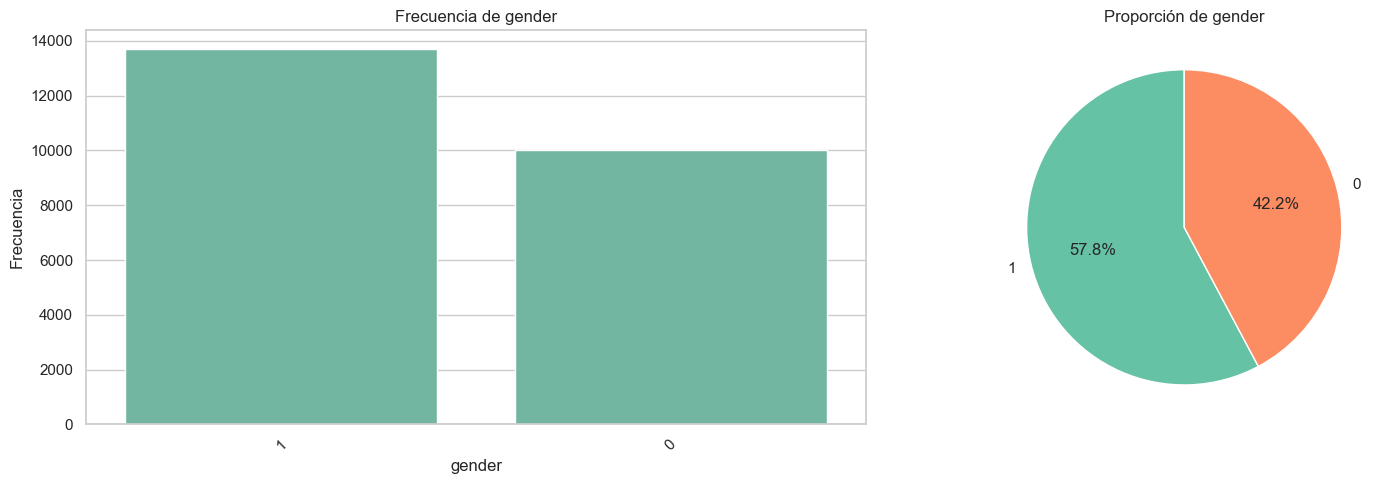

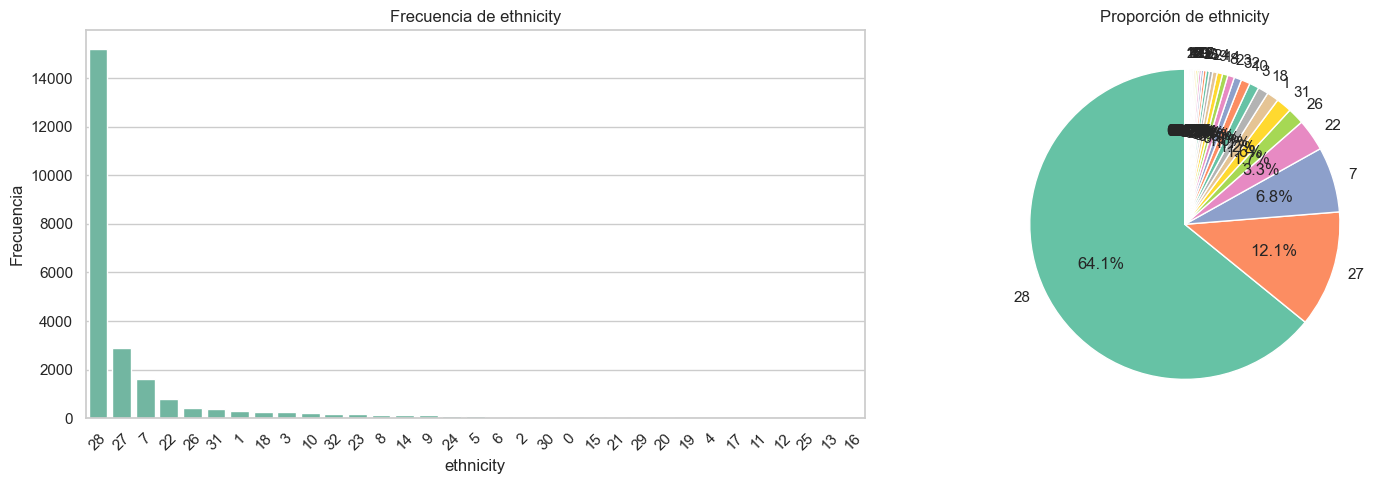

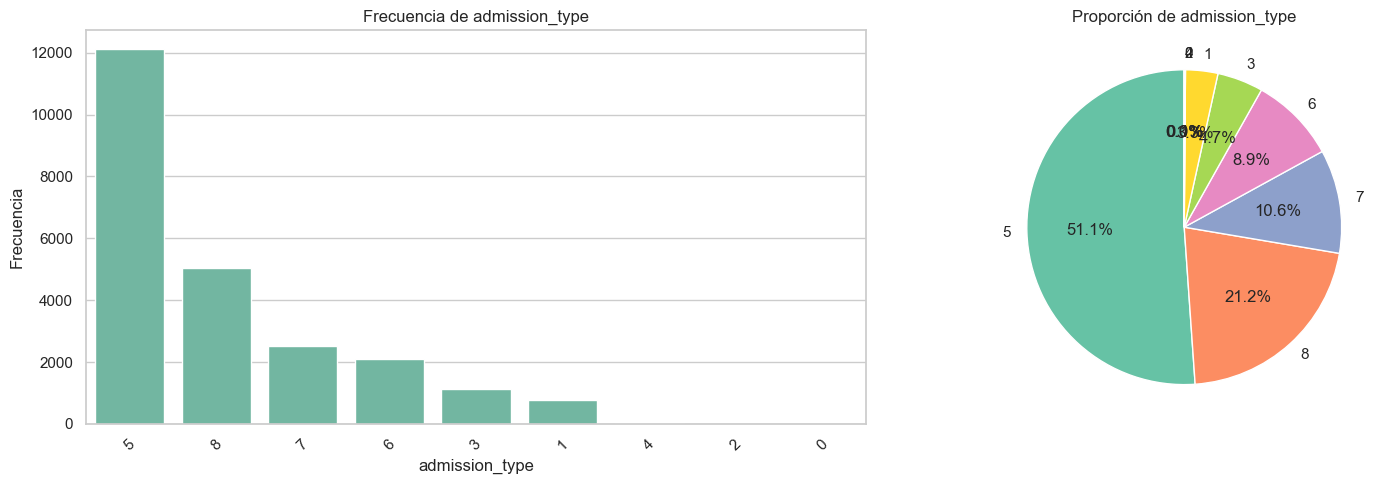

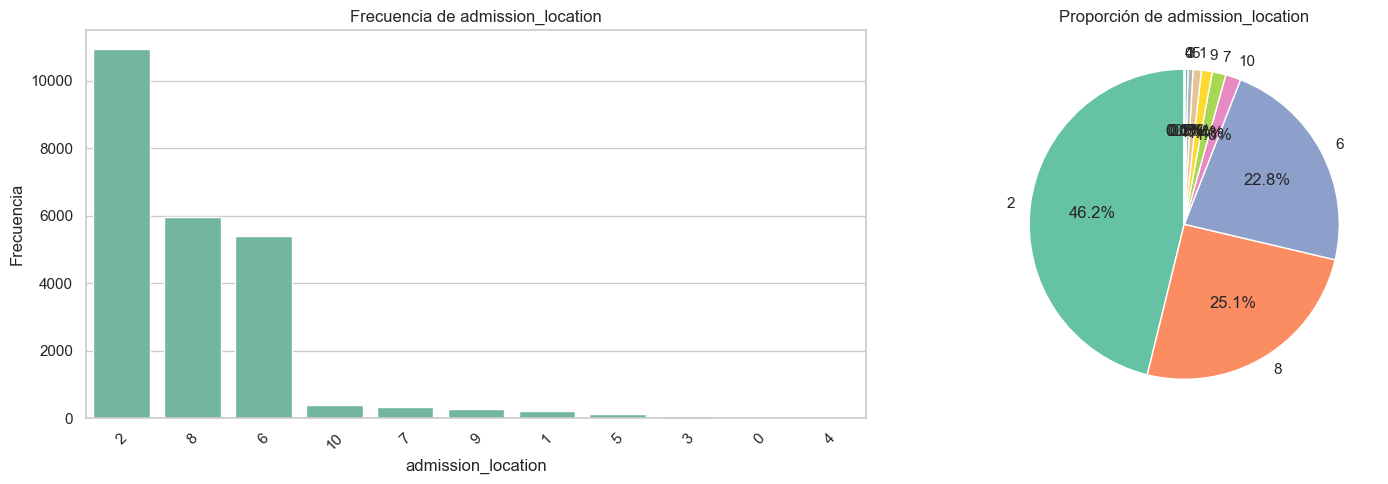

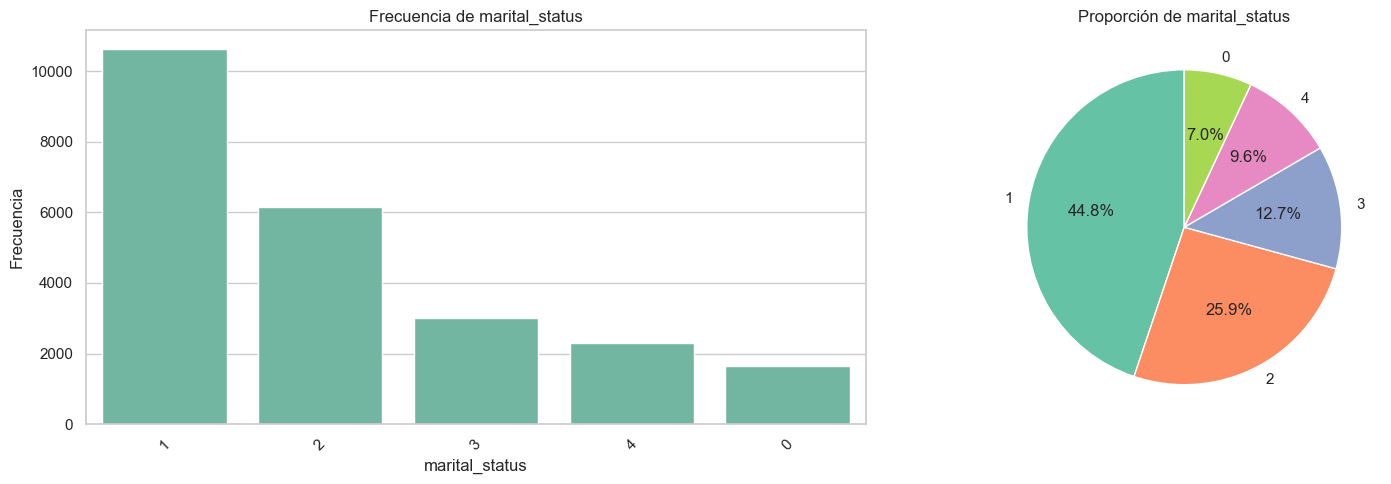

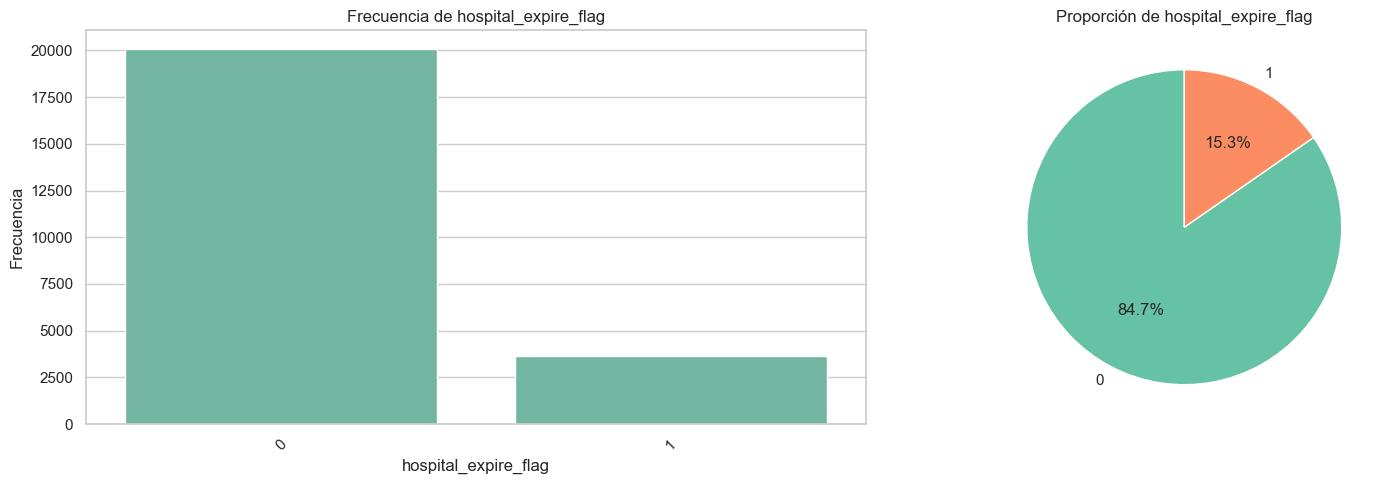

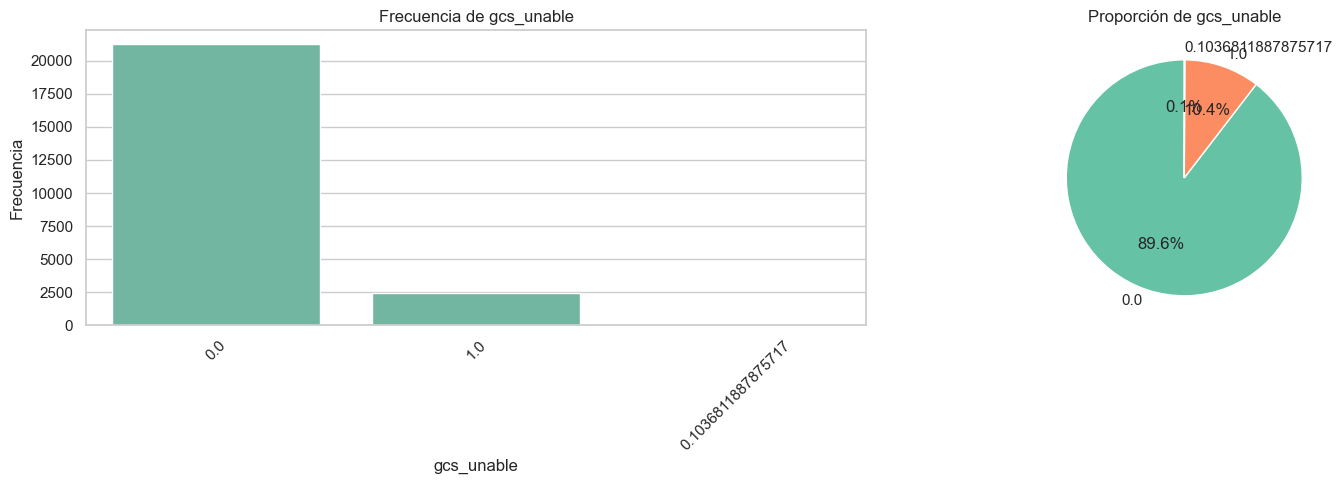

In [19]:
def plot_categorical(series, title, top_n=None):
    counts = series.value_counts(dropna=False)
    if top_n is not None:
        counts = counts.head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values,
        ax=axes[0],
        color=sns.color_palette()[0]
    )
    axes[0].set_title(f'Frecuencia de {title}')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('Frecuencia')
    axes[0].tick_params(axis='x', rotation=45)

    proportions = (counts / counts.sum() * 100).round(2)
    axes[1].pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90
    )
    axes[1].set_title(f'Proporción de {title}')

    plt.tight_layout()
    plt.show()


for col in categorical_vars:
    plot_categorical(df[col], col)


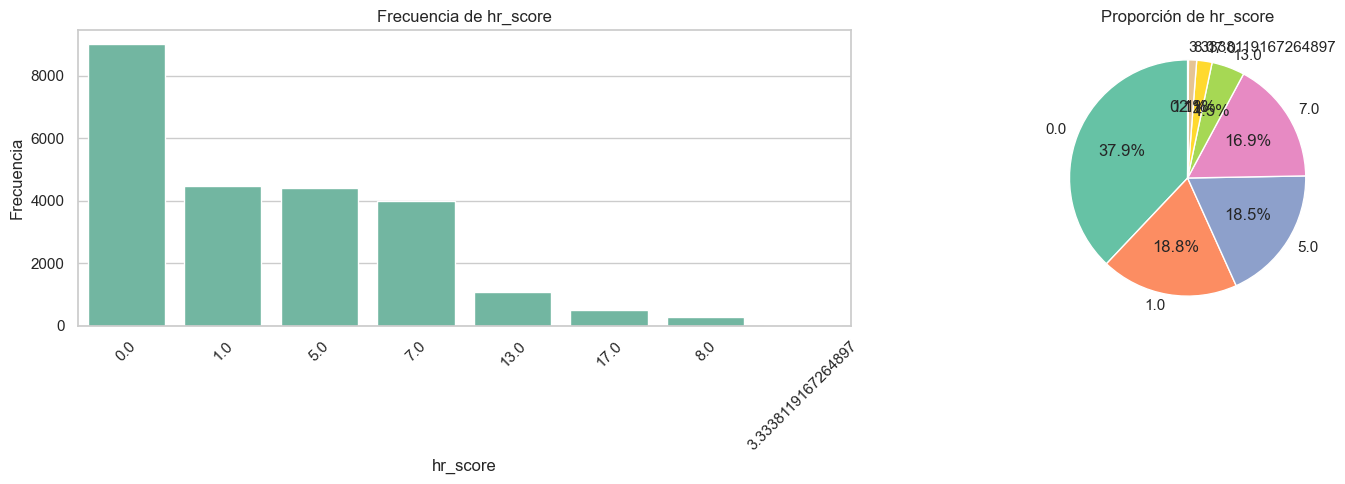

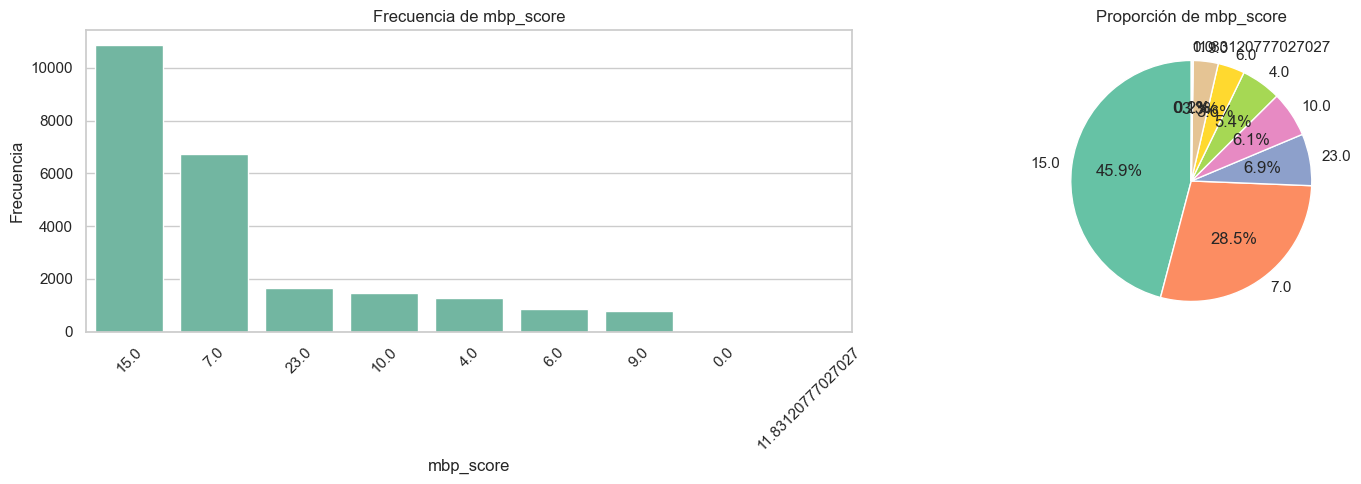

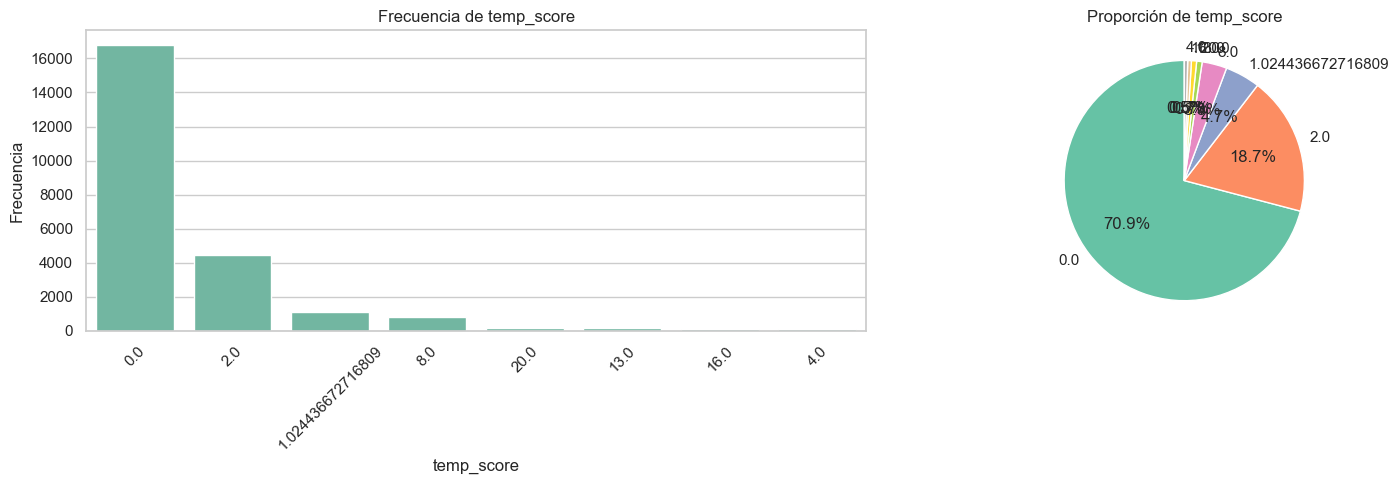

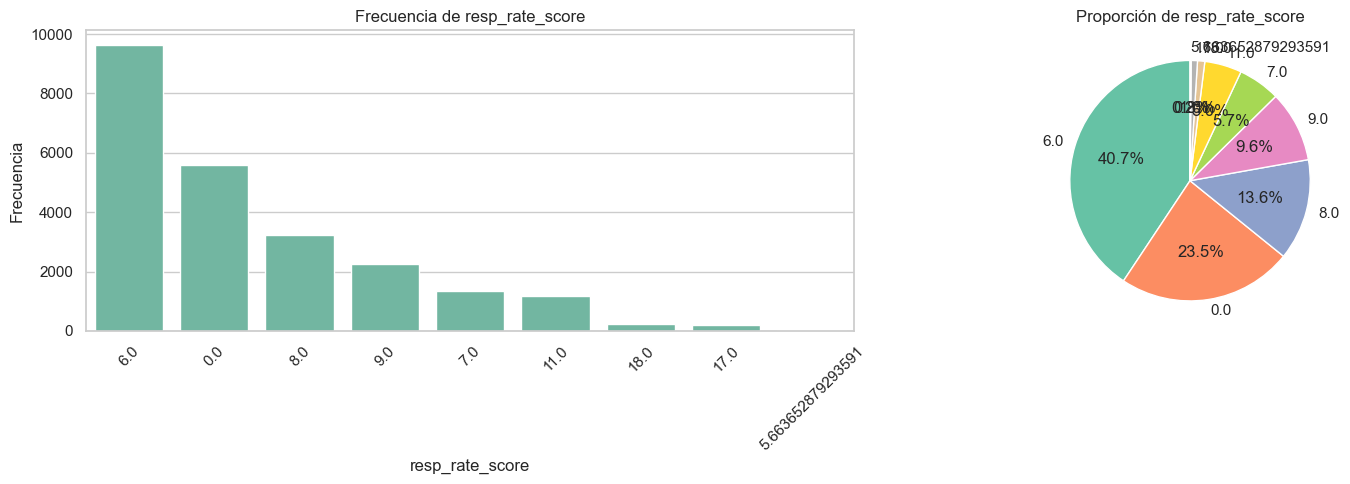

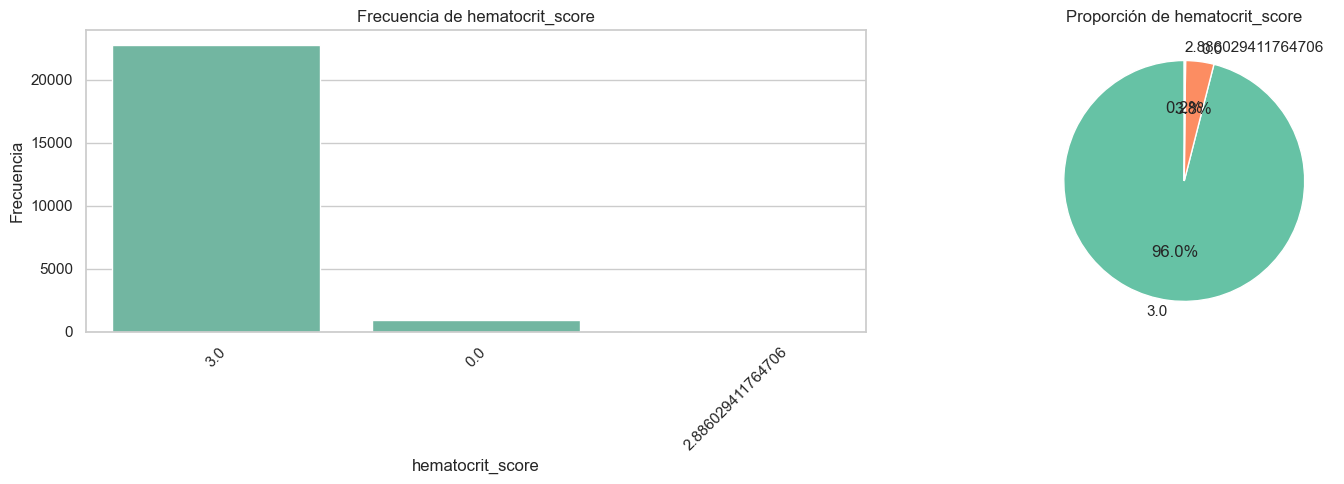

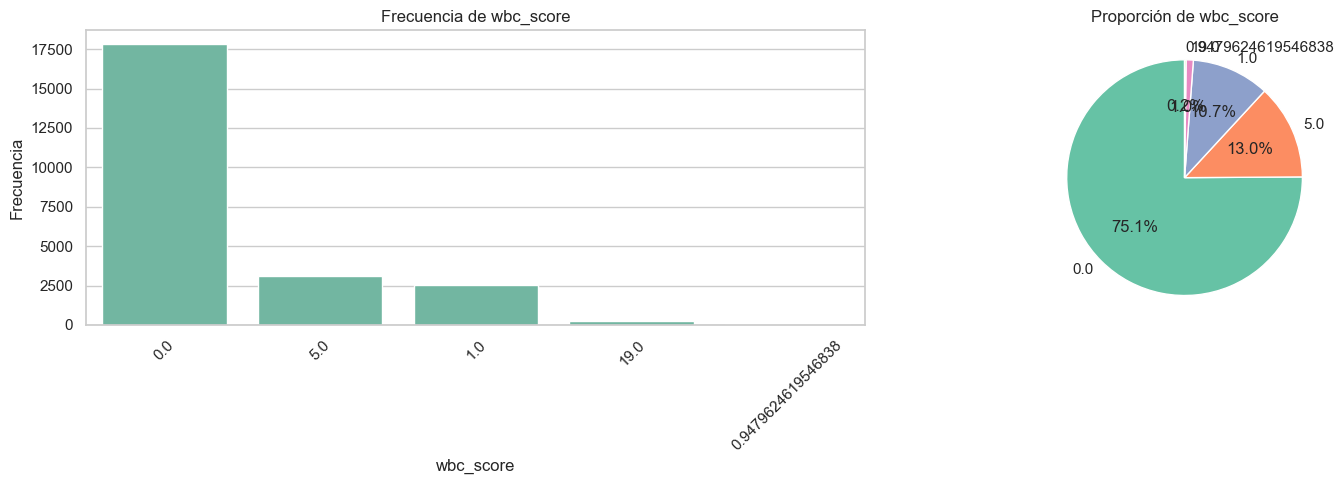

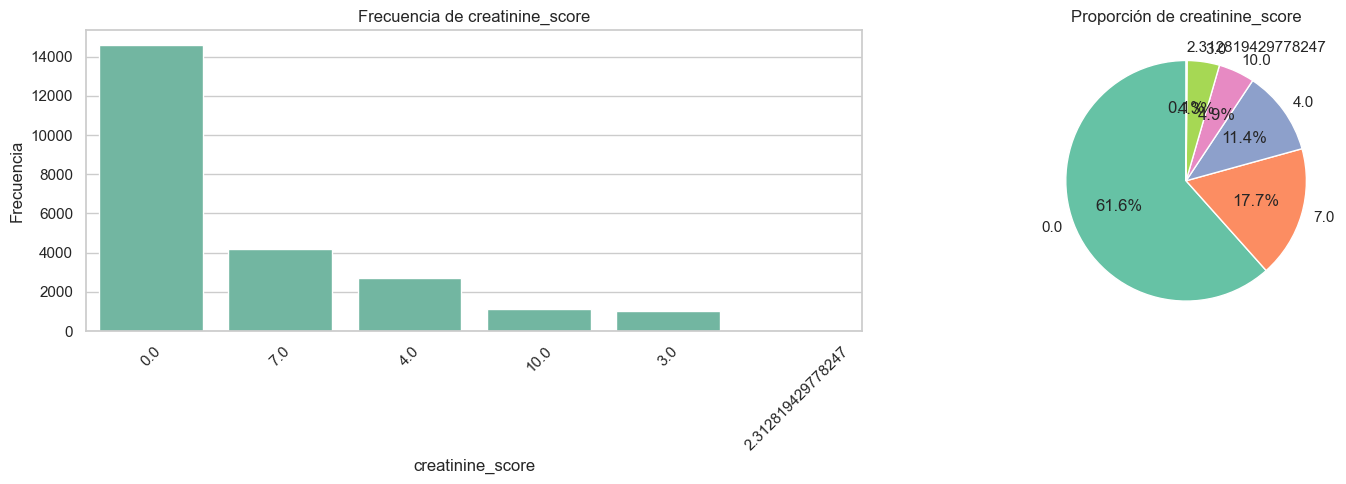

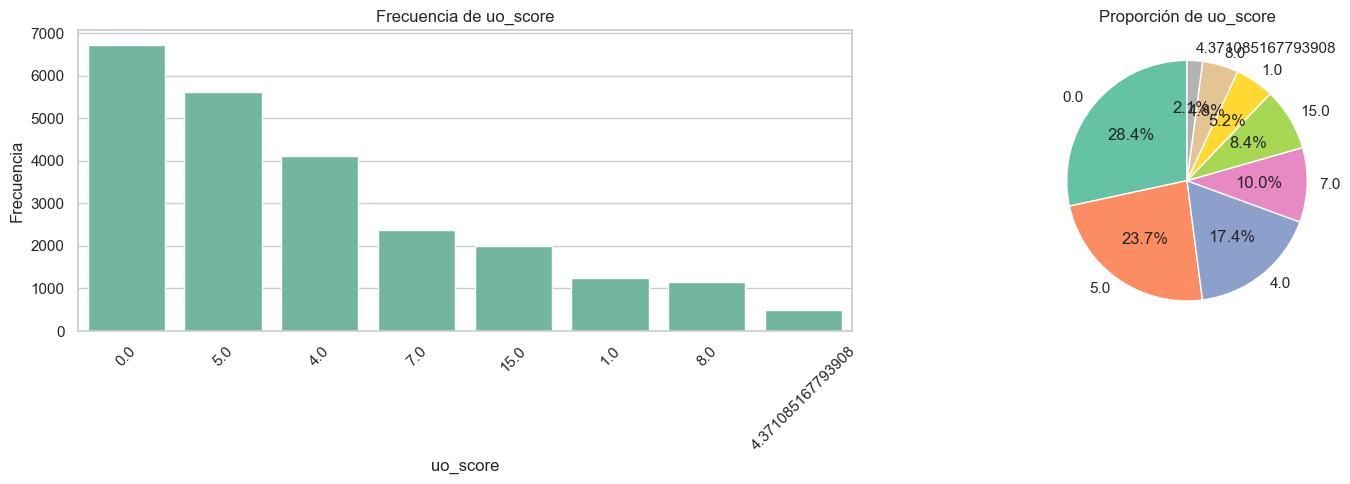

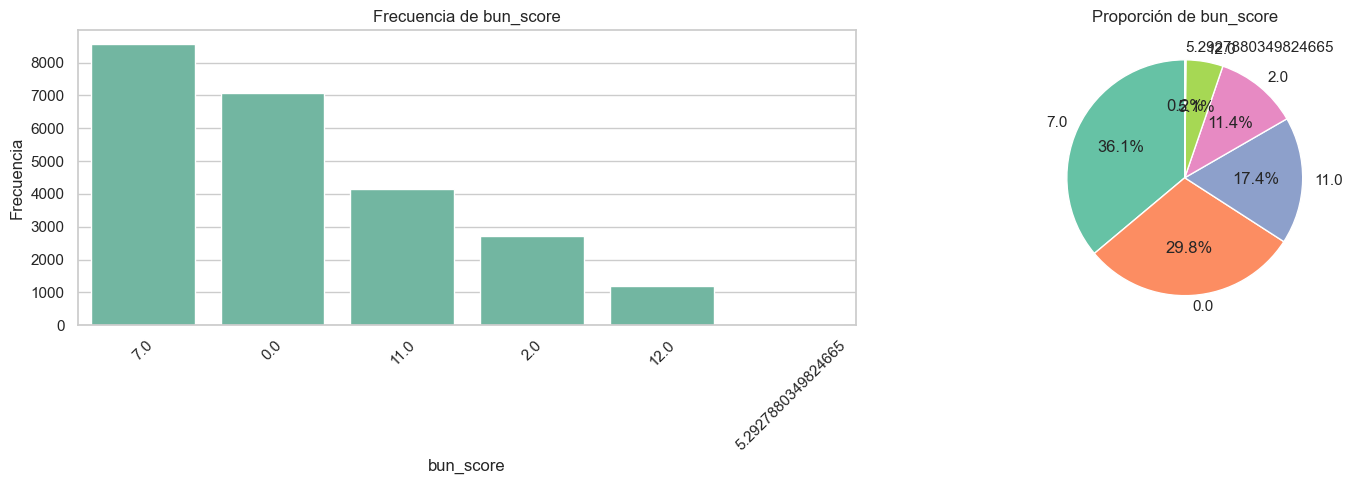

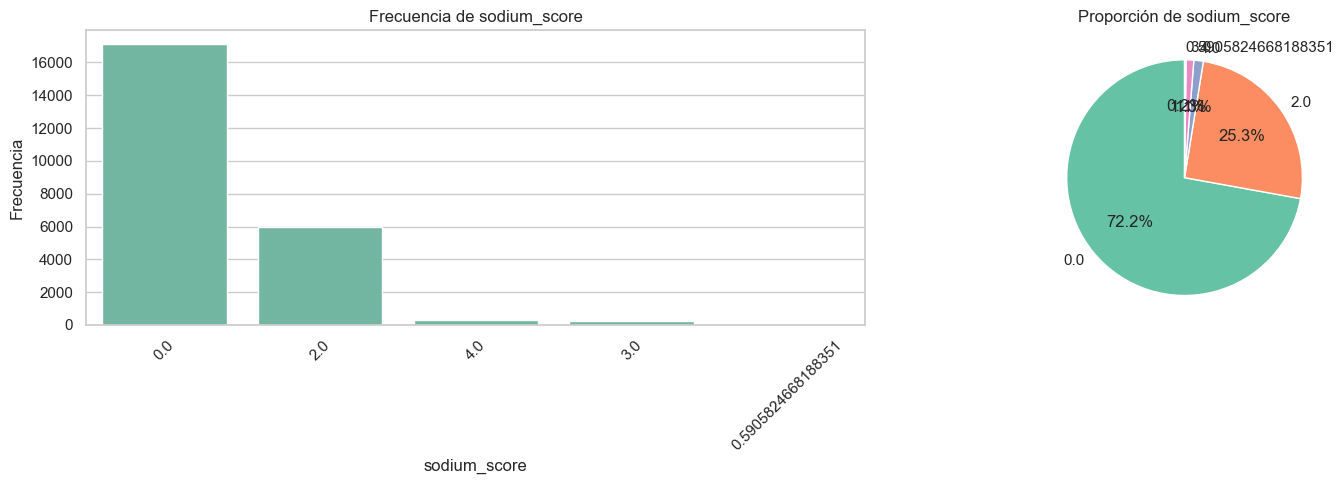

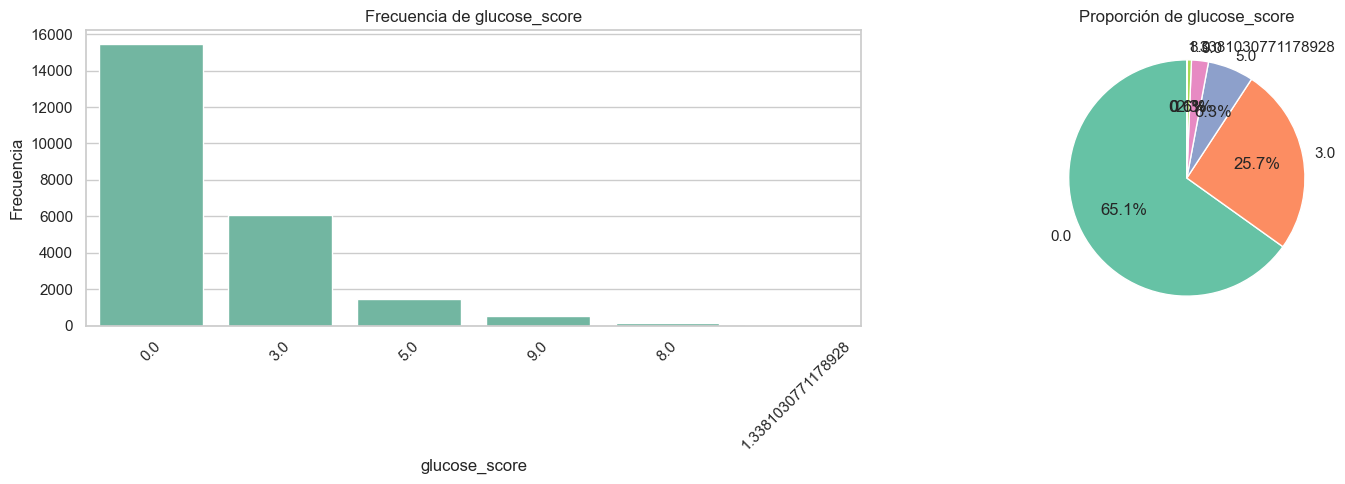

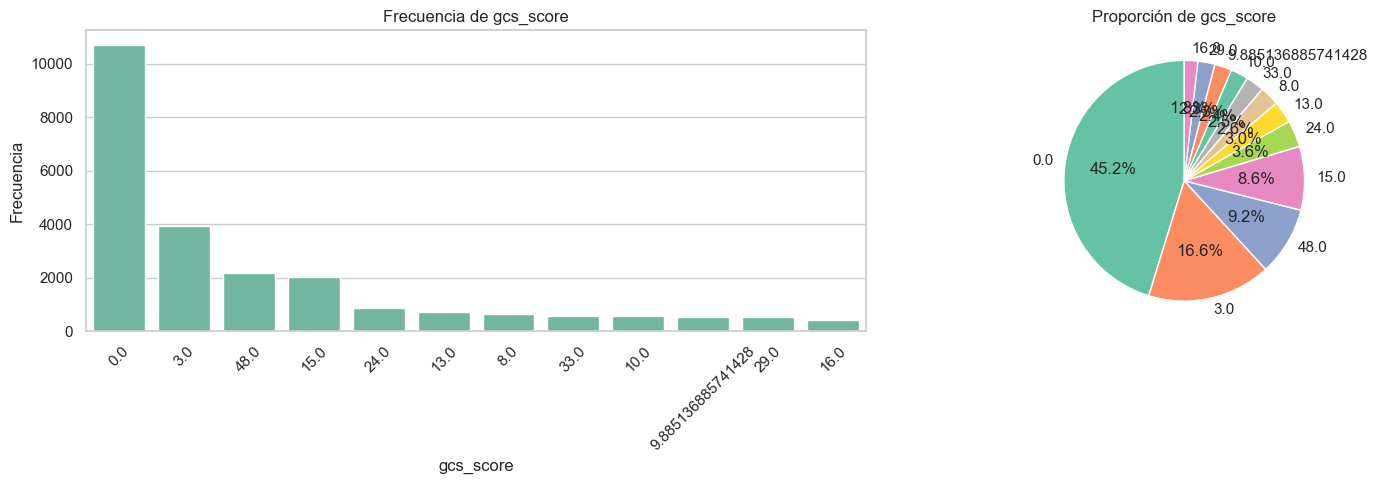

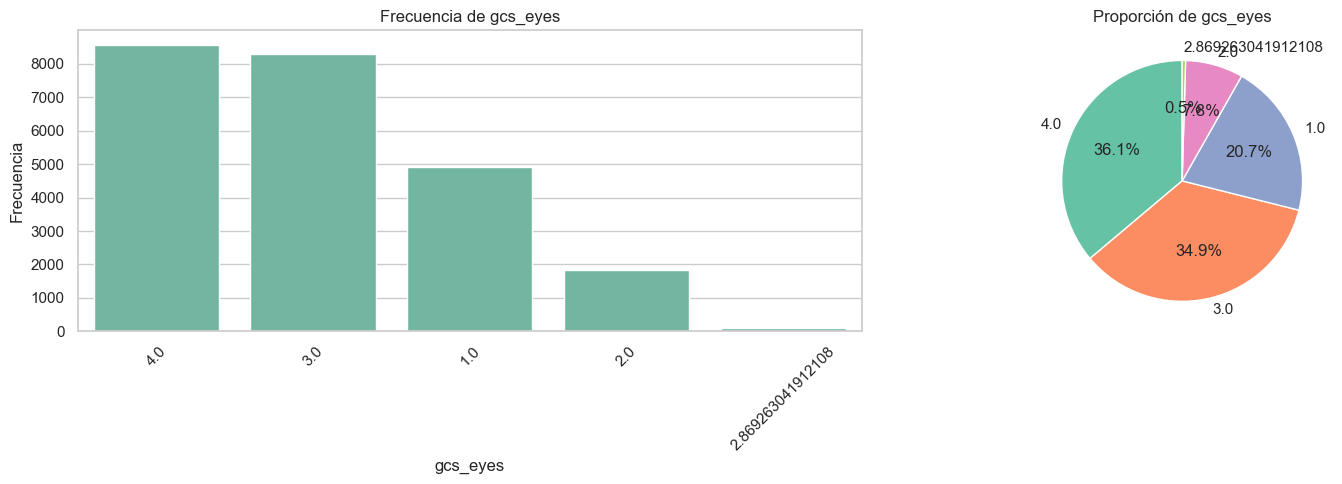

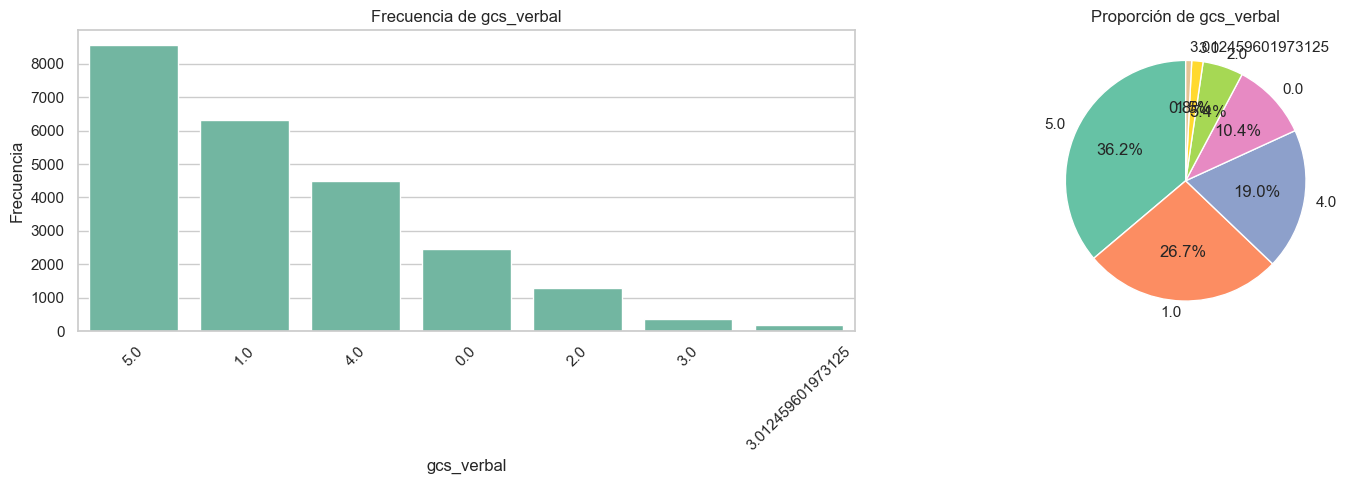

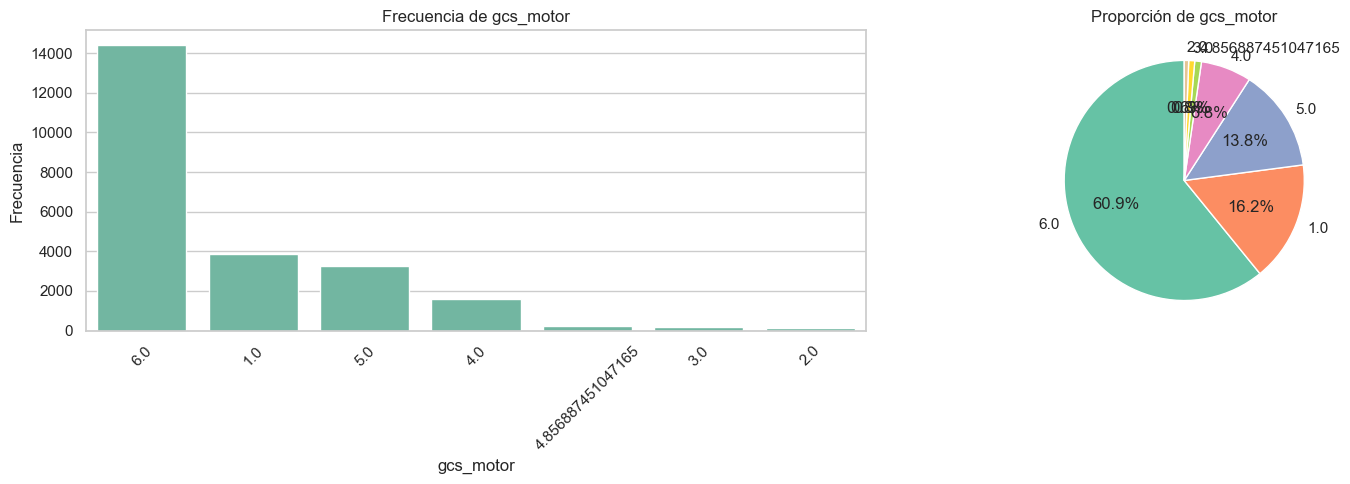

In [20]:
for col in ordinal_vars:
    plot_categorical(df[col], col)


## Análisis univariante: variables numéricas

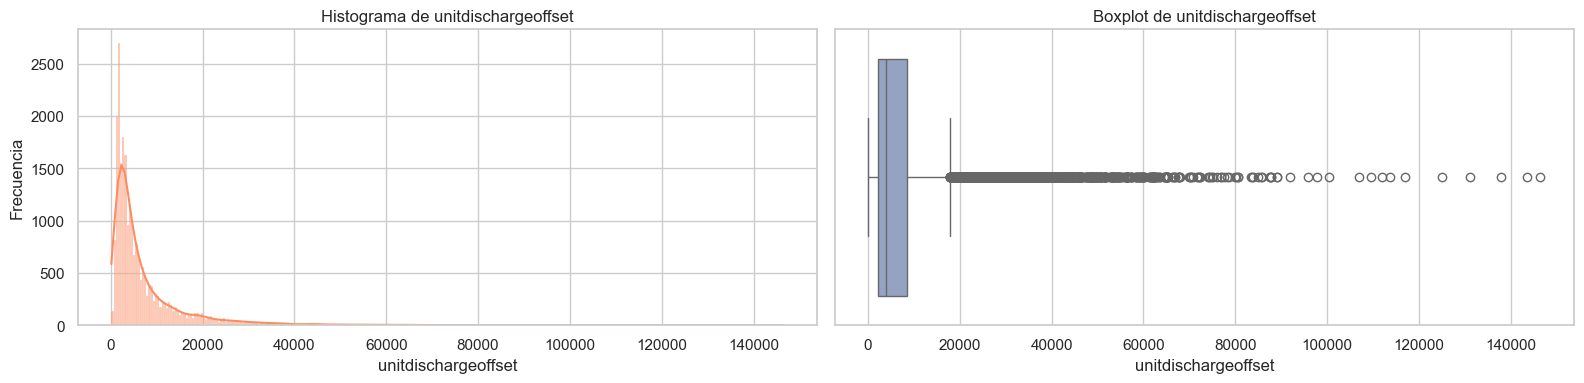

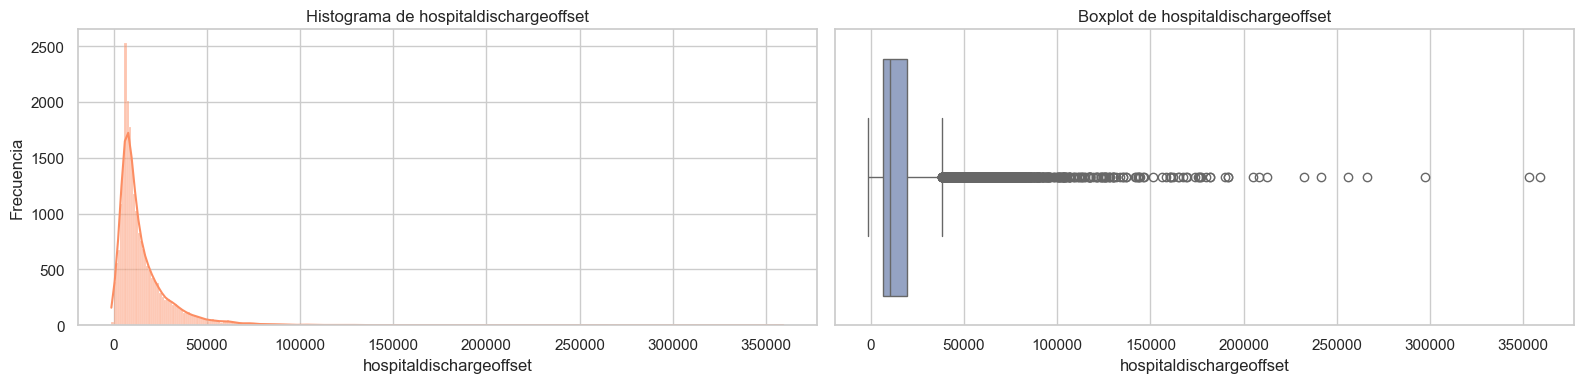

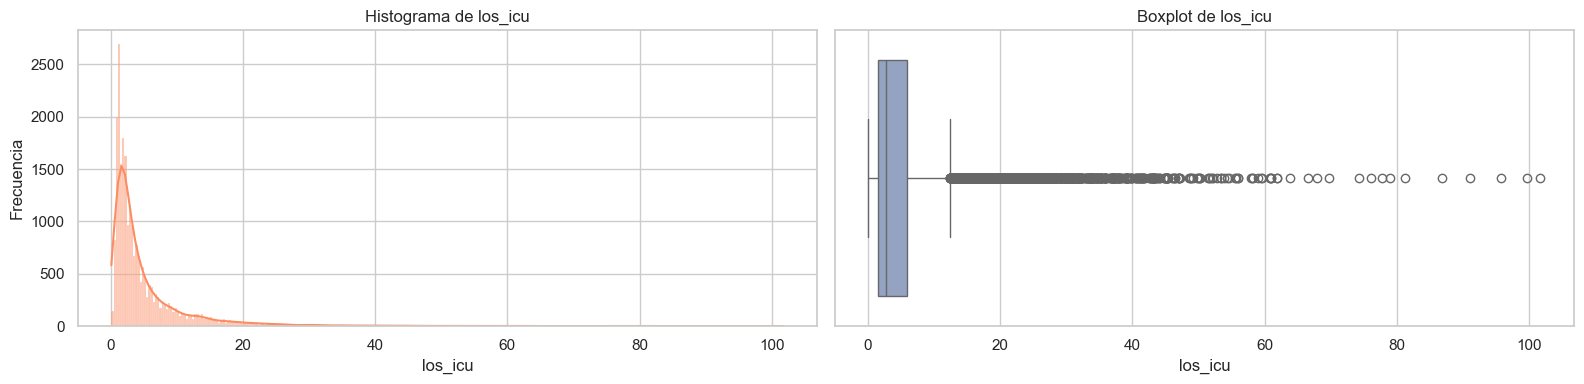

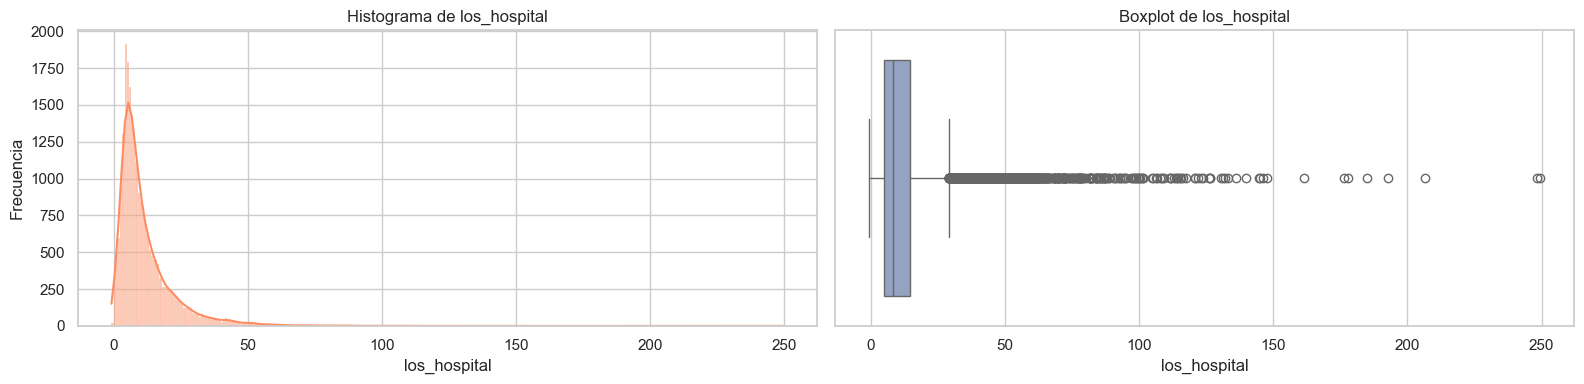

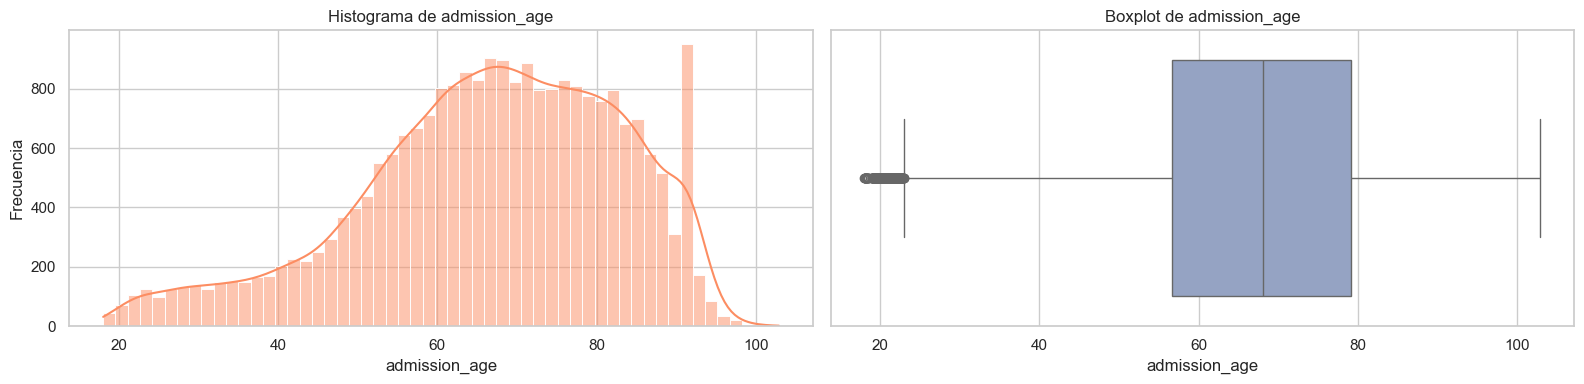

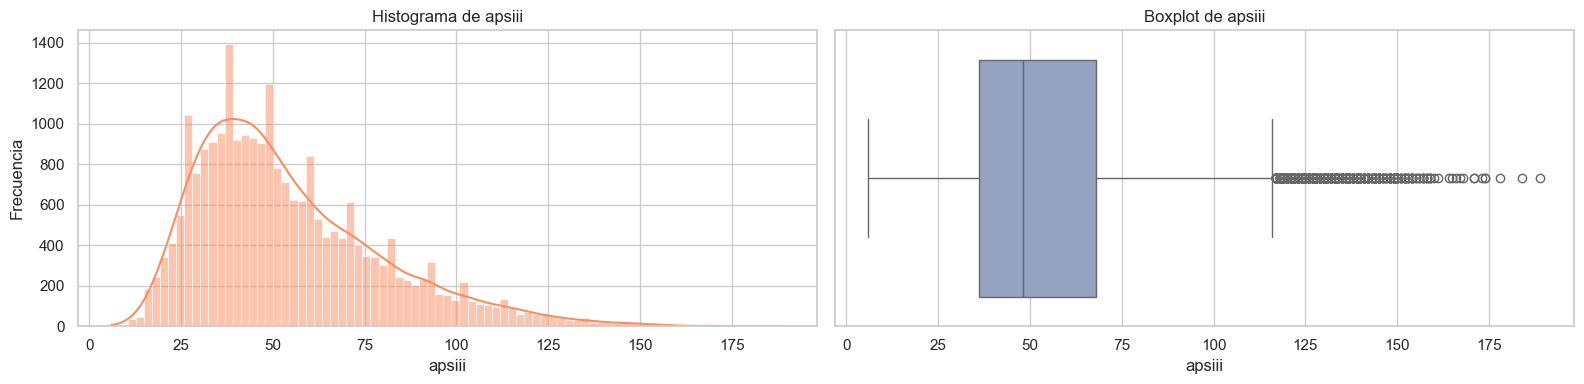

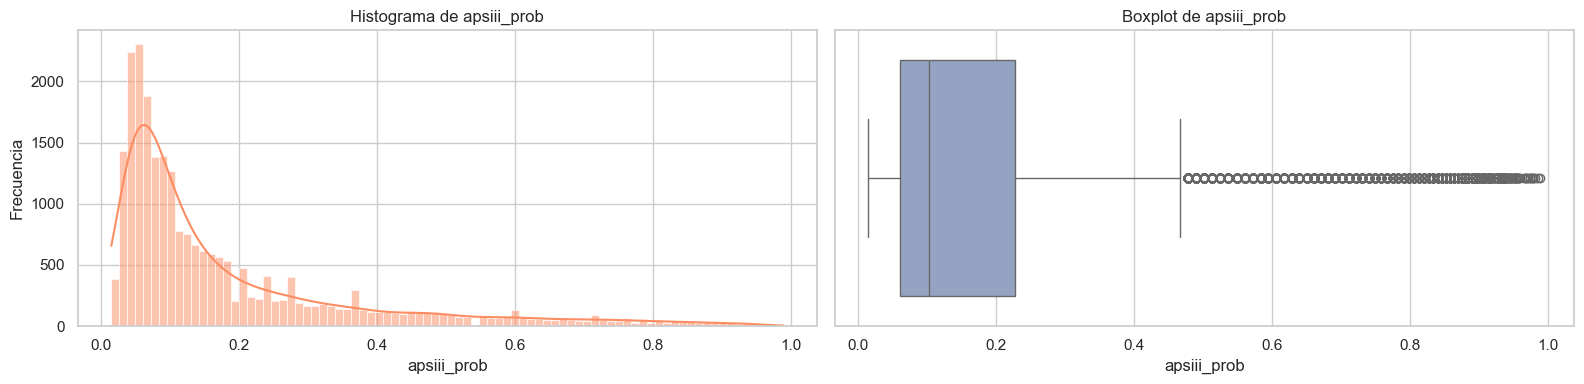

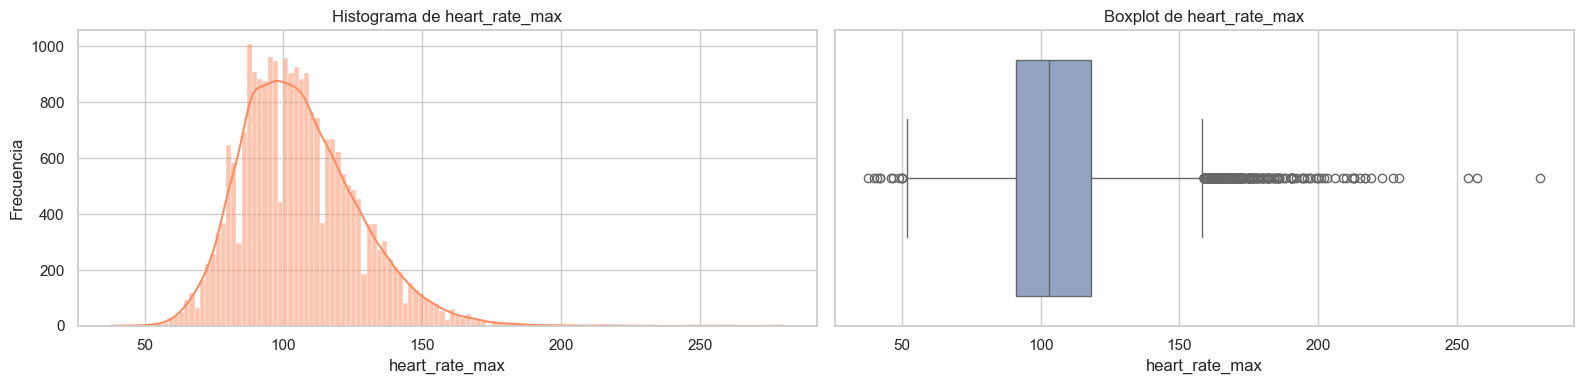

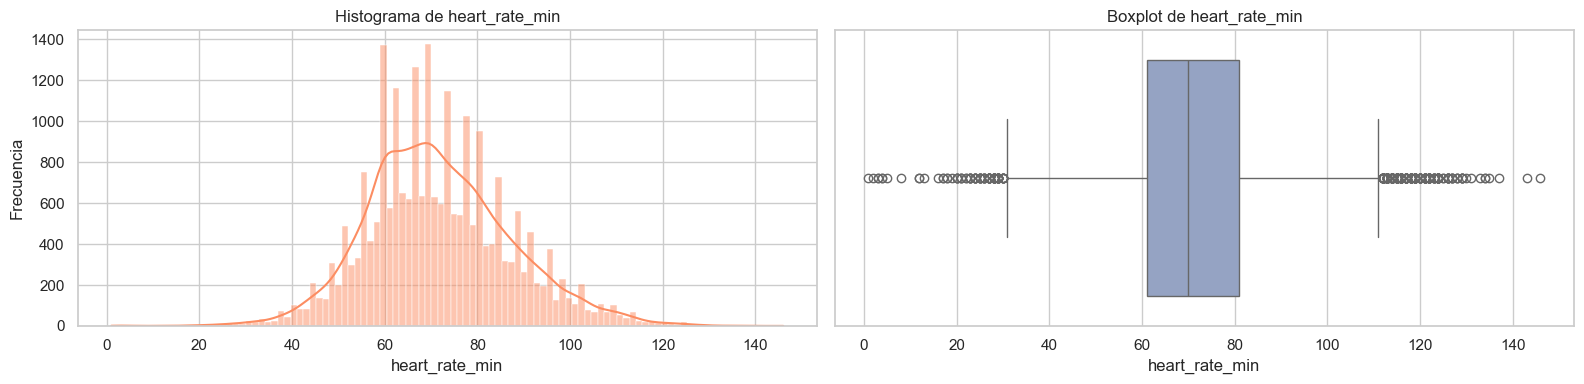

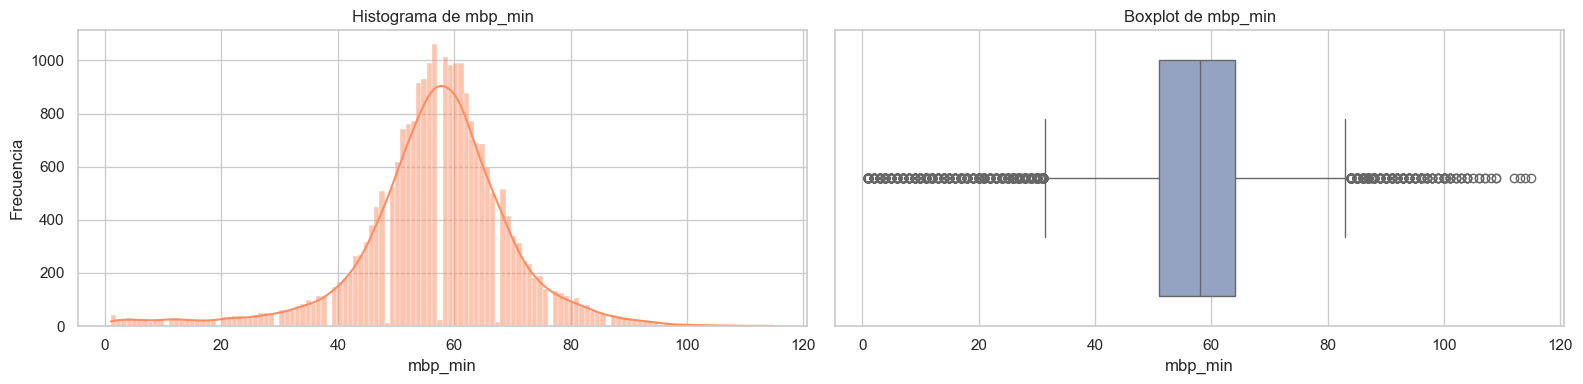

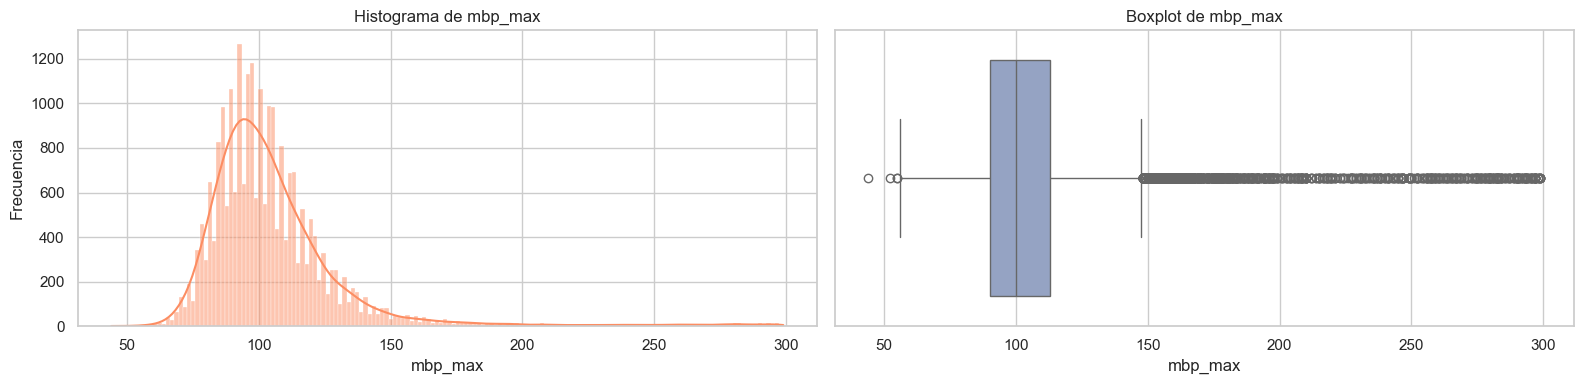

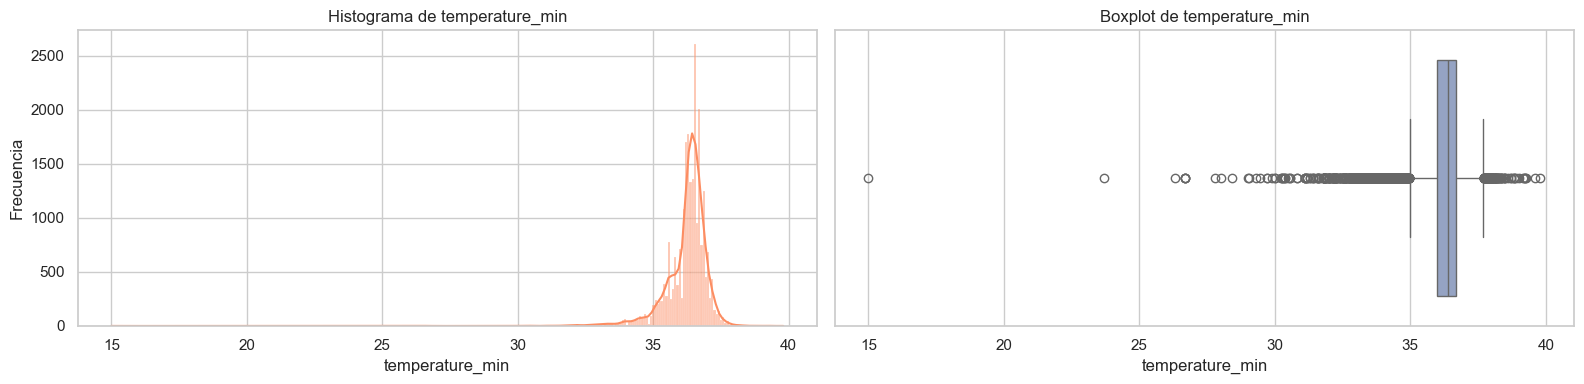

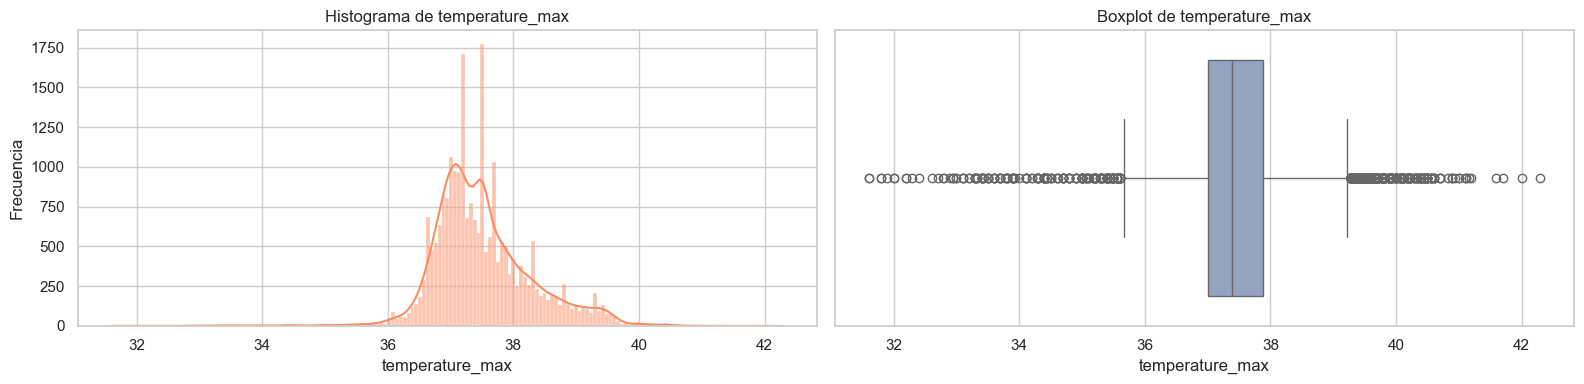

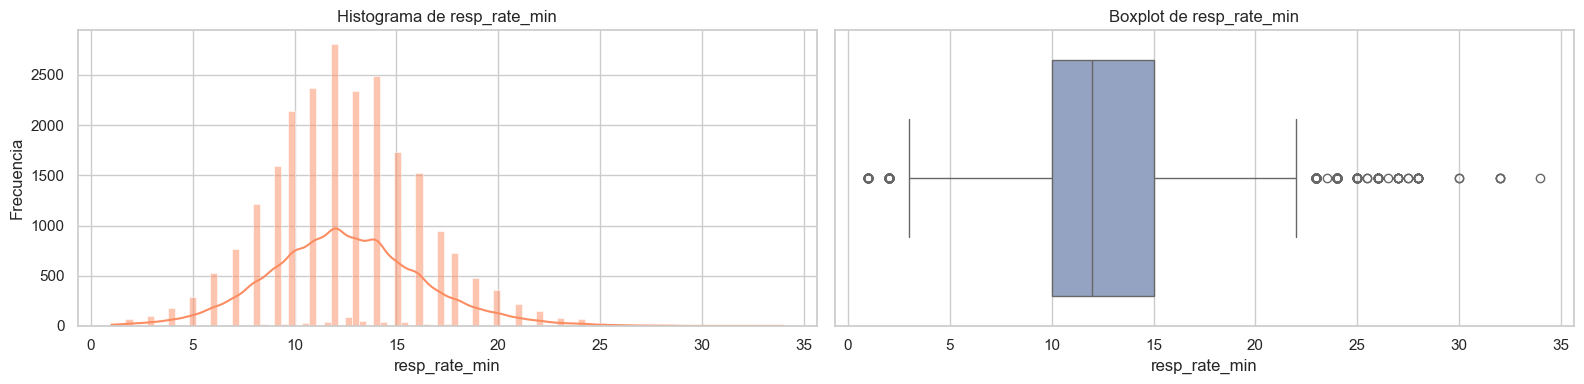

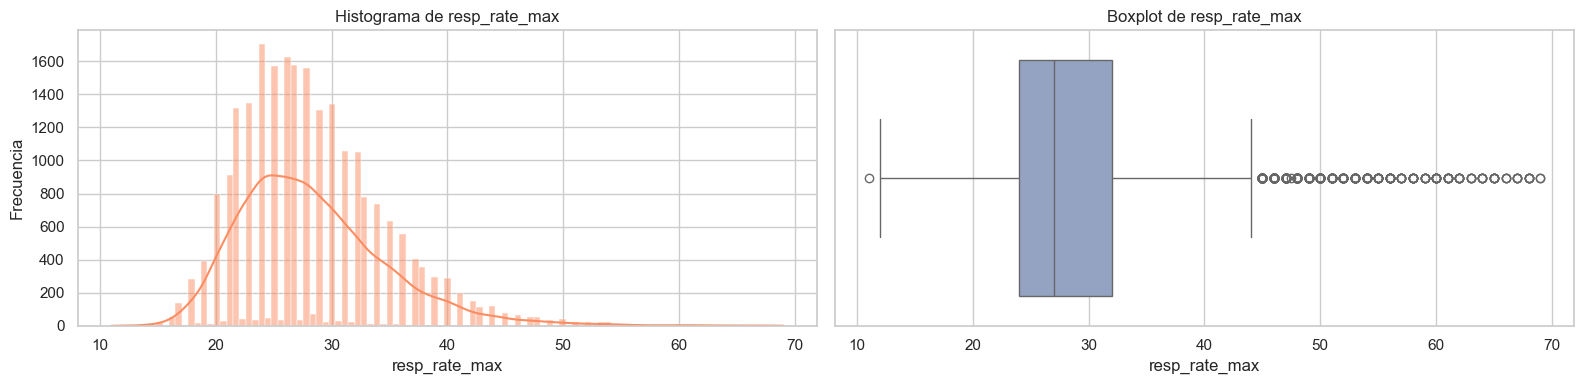

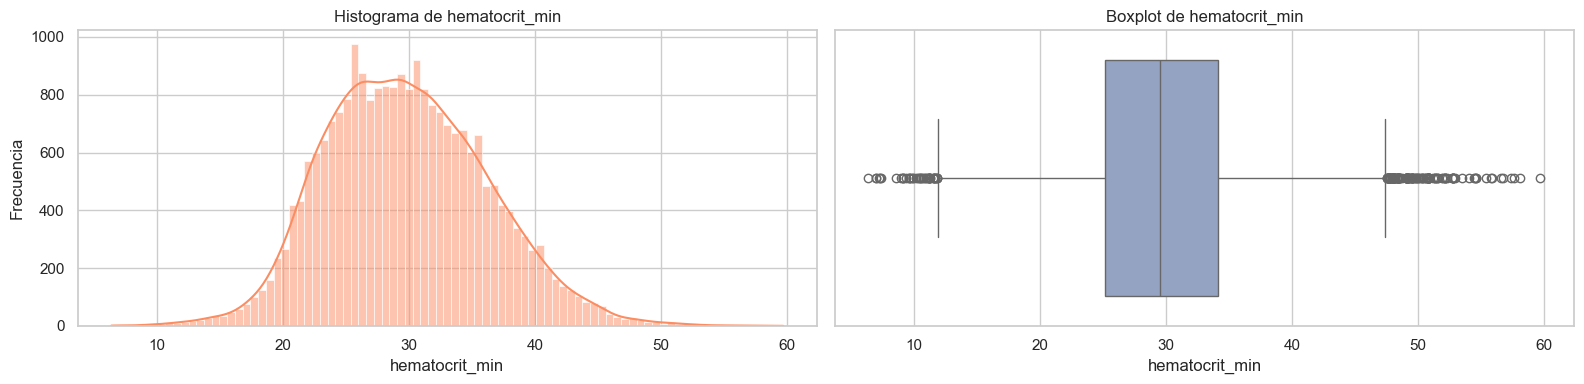

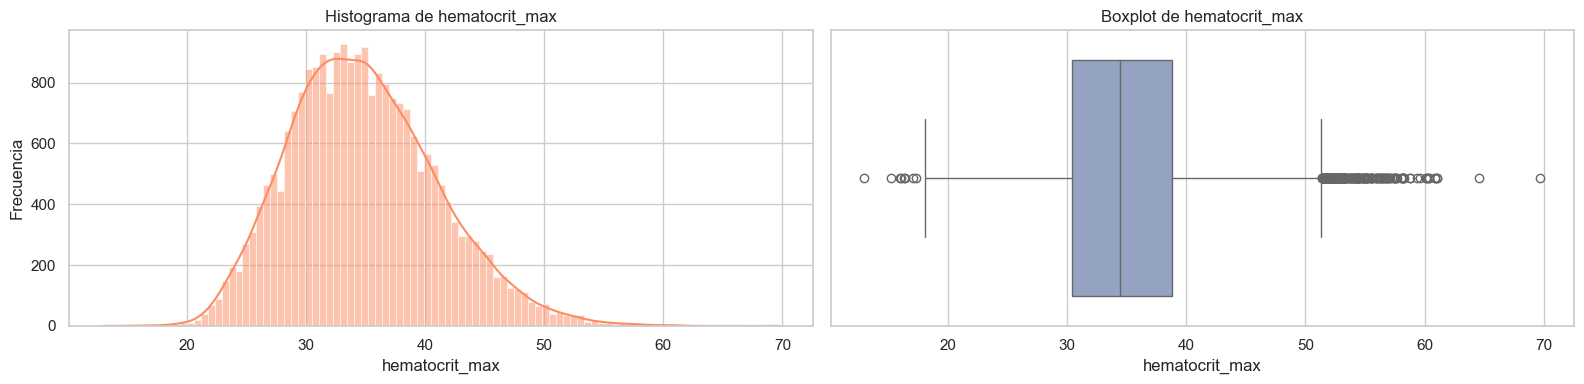

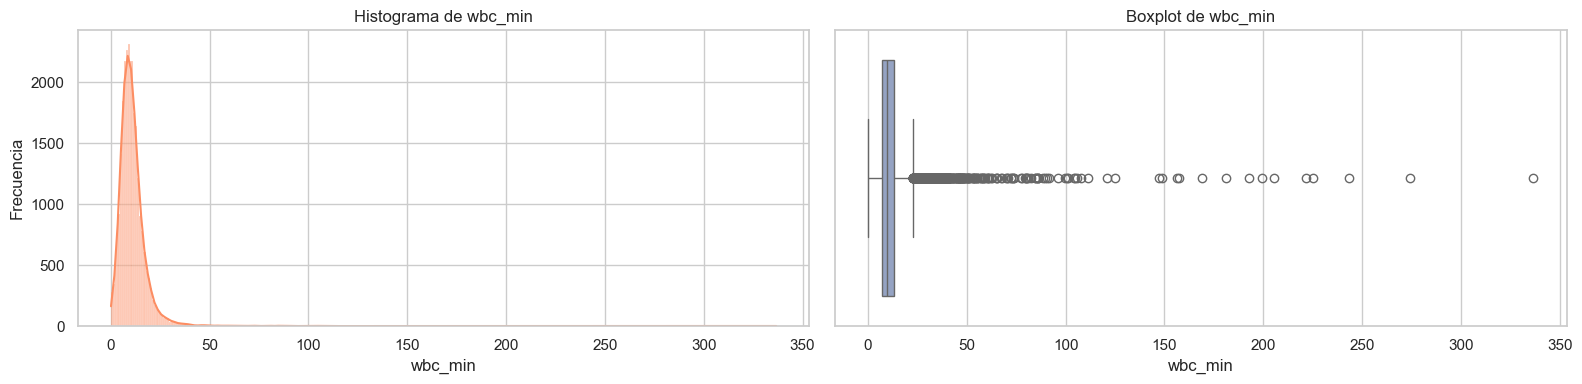

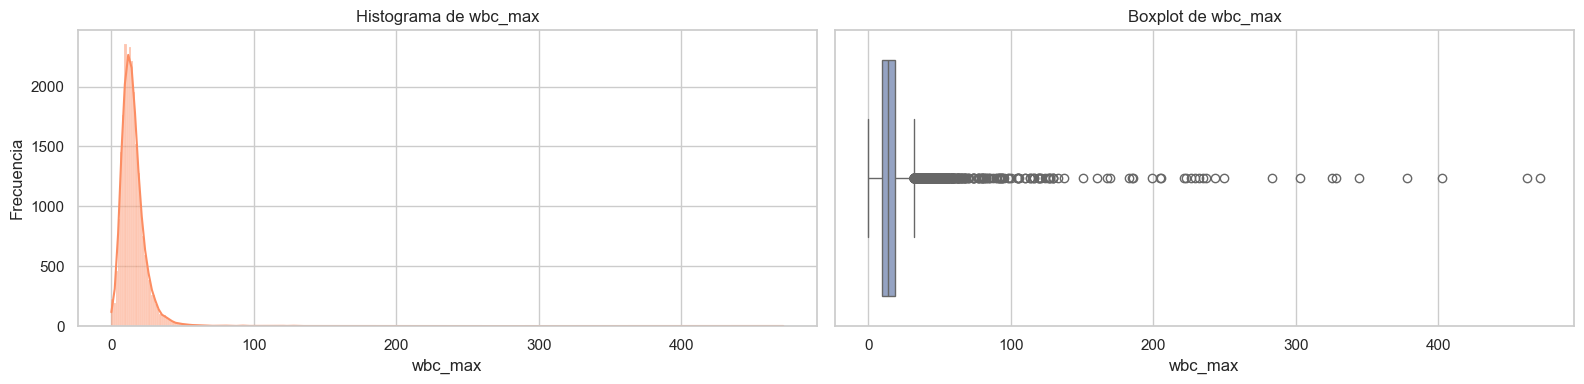

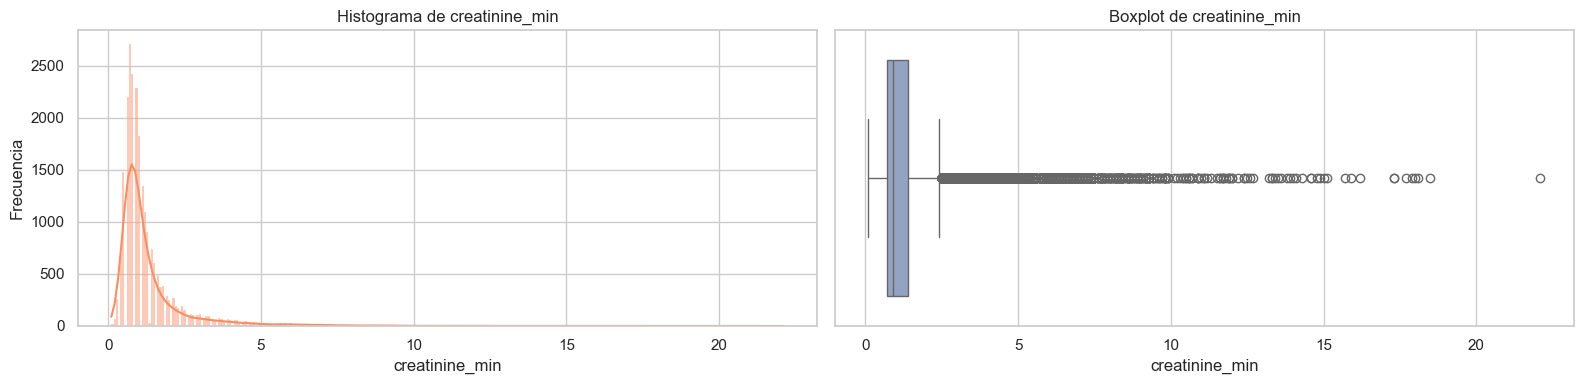

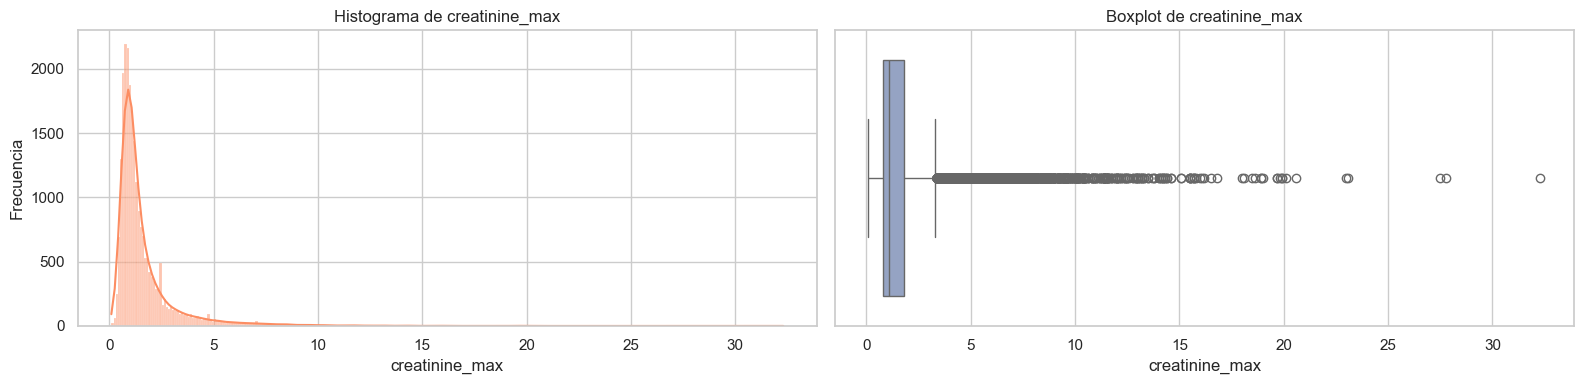

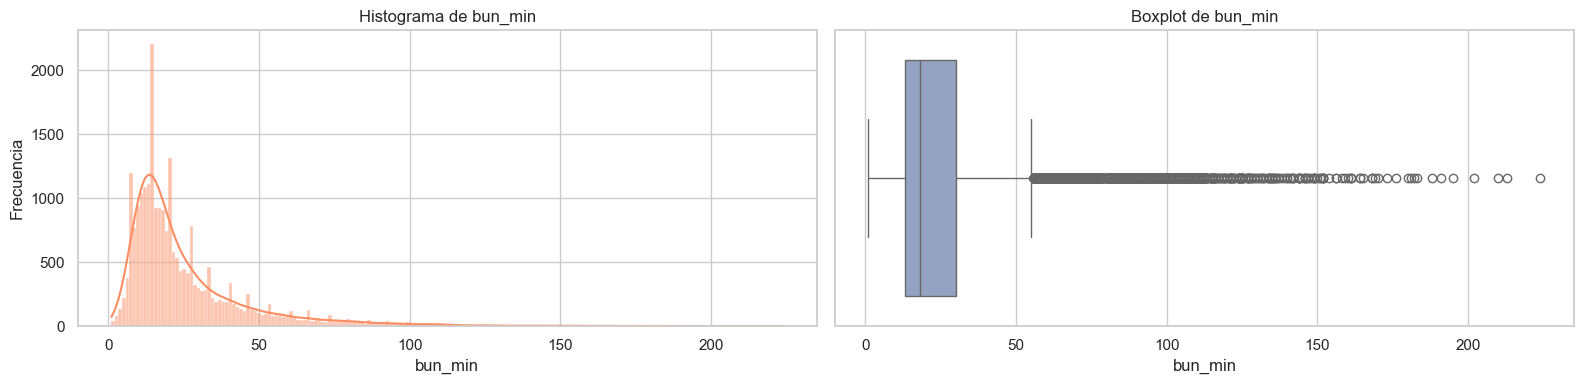

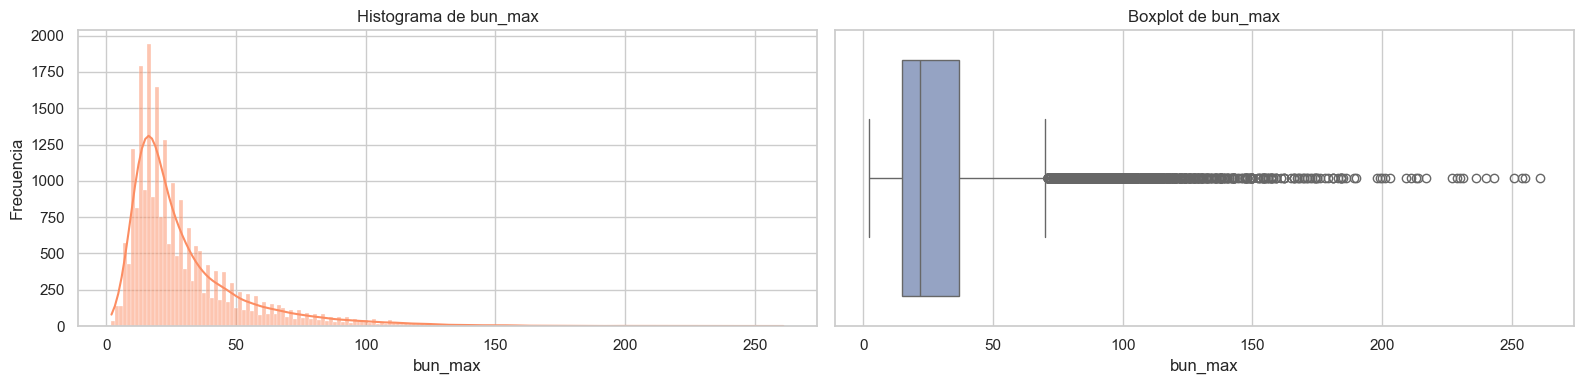

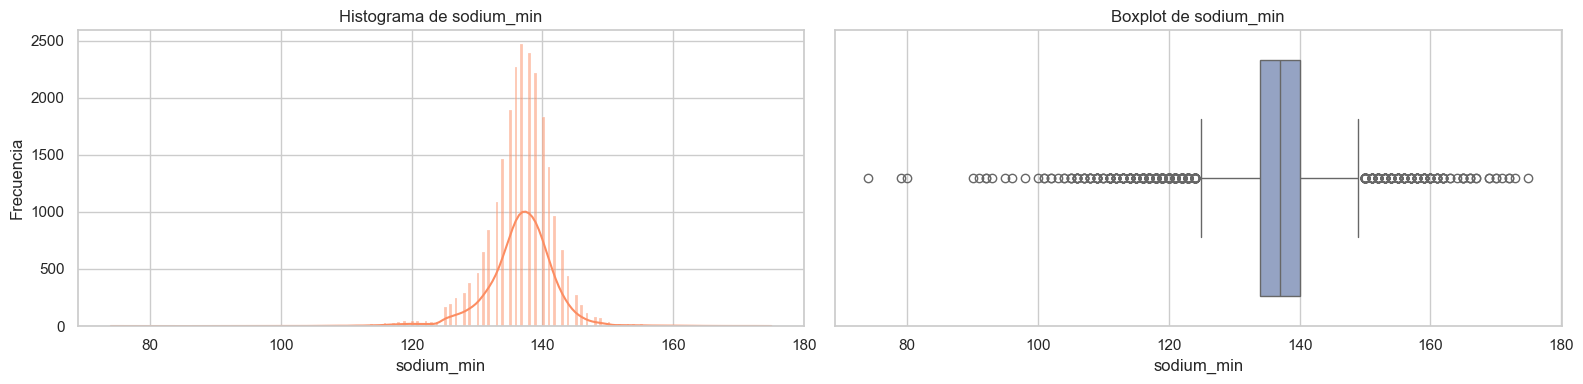

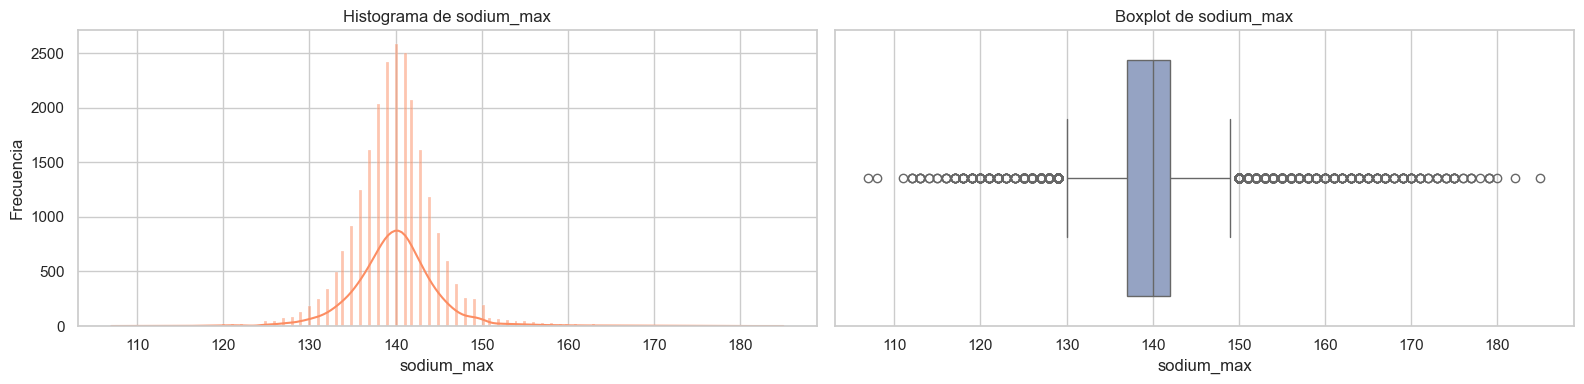

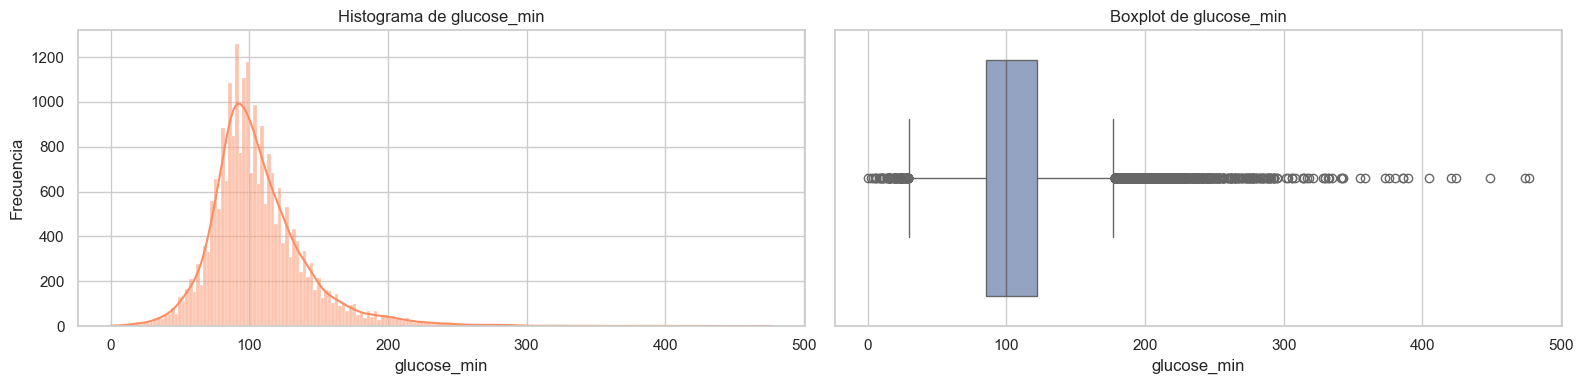

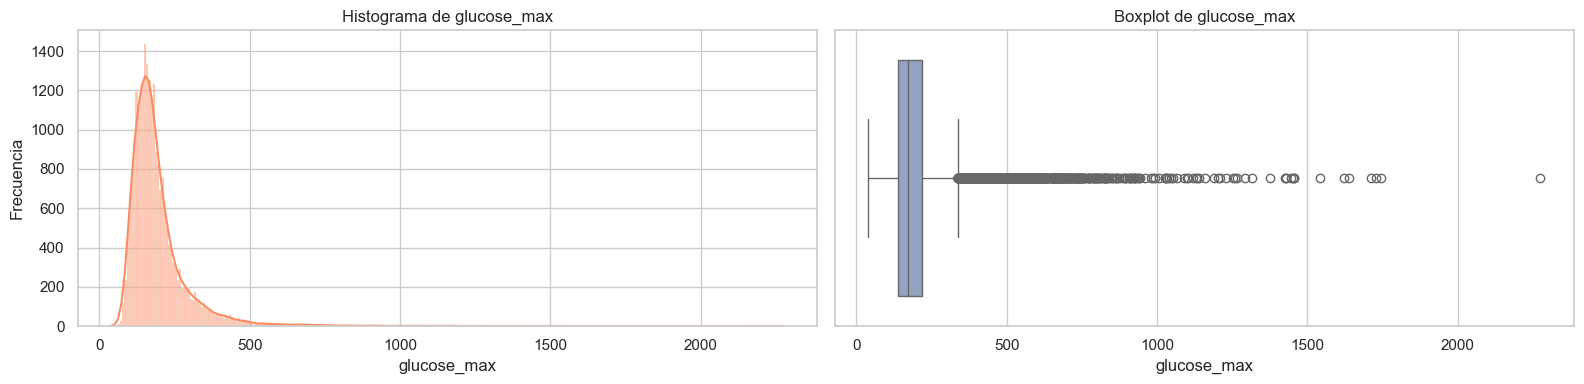

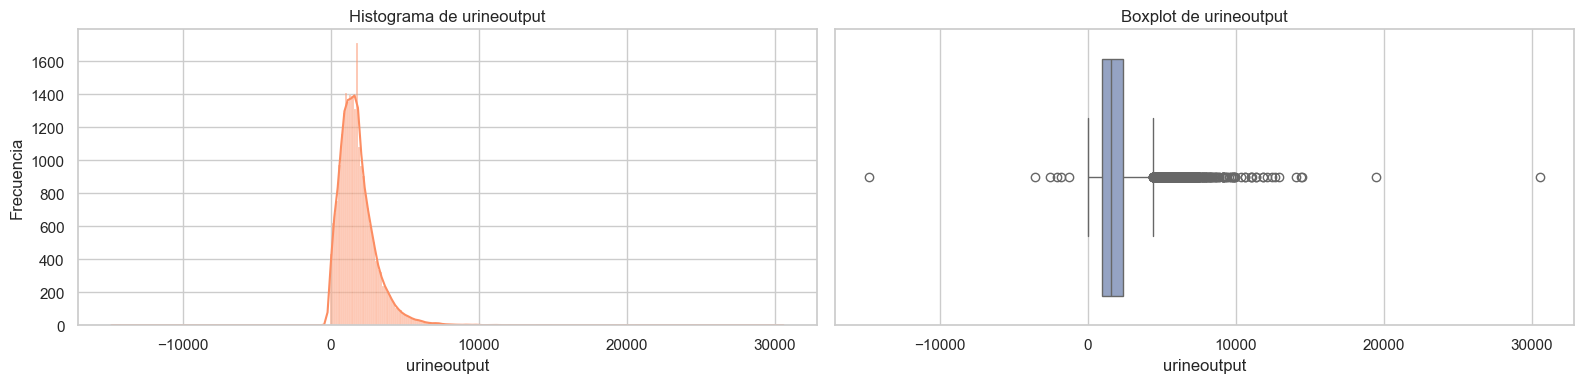

In [21]:
def plot_numeric(series, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    sns.histplot(series.dropna(), kde=True, ax=axes[0], color=sns.color_palette()[1])
    axes[0].set_title(f'Histograma de {title}')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('Frecuencia')

    sns.boxplot(x=series.dropna(), ax=axes[1], color=sns.color_palette()[2])
    axes[1].set_title(f'Boxplot de {title}')
    axes[1].set_xlabel(title)

    plt.tight_layout()
    plt.show()


for col in temporal_numeric_vars:
    plot_numeric(df[col], col)

for col in continuous_vars:
    plot_numeric(df[col], col)


## Estudio de correlación global

Se usa correlación de Spearman porque:

- muchas variables están codificadas de forma ordinal;
- varias distribuciones son asimétricas;
- nos interesa capturar relaciones monótonas además de lineales.


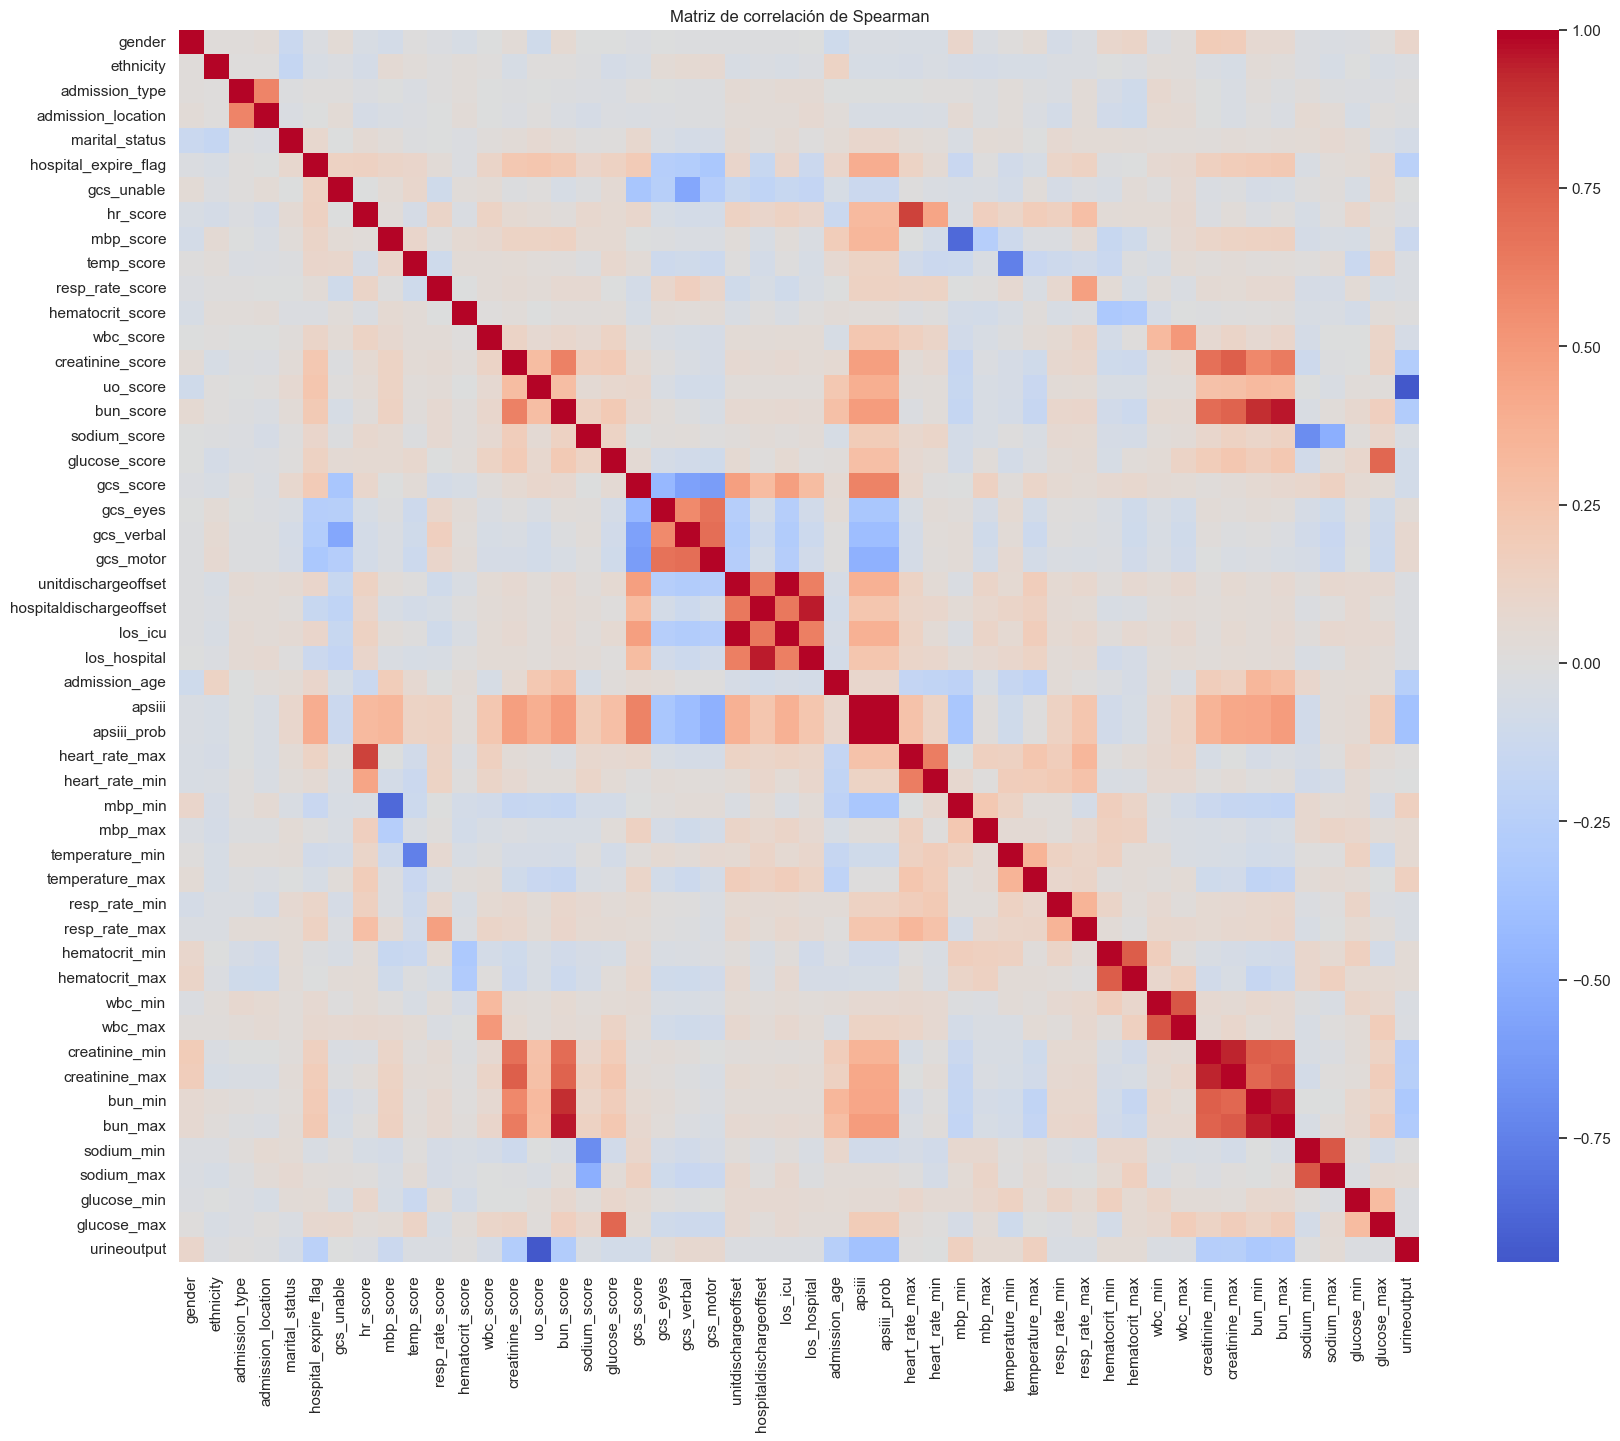

In [22]:
analysis_cols = [col for col in all_typed_vars if col in df.columns]
corr_spearman = df[analysis_cols].corr(method='spearman')

plt.figure(figsize=(20, 16))
sns.heatmap(corr_spearman, cmap='coolwarm', center=0, square=False)
plt.title('Matriz de correlación de Spearman')
plt.show()


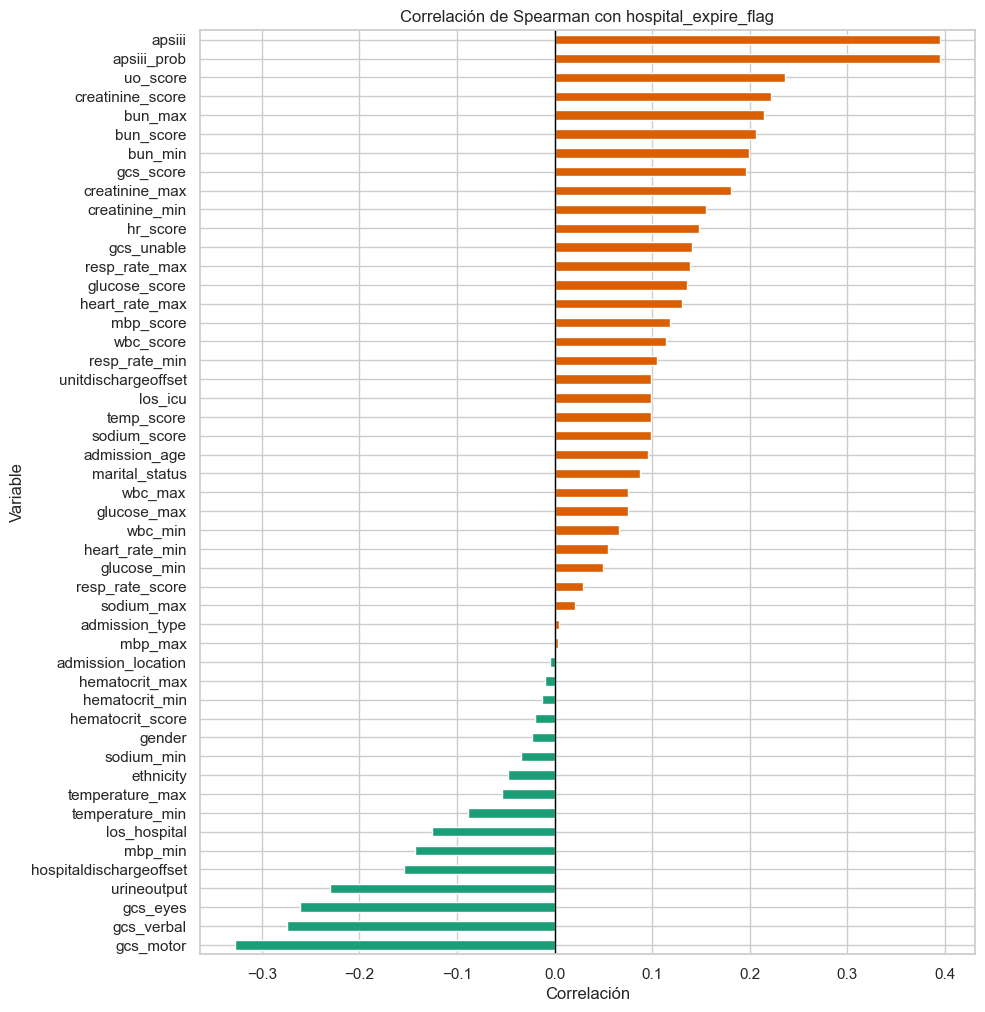

,spearman_con_mortalidad
apsiii_prob,0.394797
apsiii,0.394797
gcs_motor,-0.327177
gcs_verbal,-0.274478
gcs_eyes,-0.260511
uo_score,0.236596
urineoutput,-0.229750
creatinine_score,0.221814
bun_max,0.214402
bun_score,0.206452


In [23]:
target_corr = corr_spearman['hospital_expire_flag'].drop('hospital_expire_flag').sort_values()

plt.figure(figsize=(10, 12))
target_corr.plot(kind='barh', color=['#d95f02' if x > 0 else '#1b9e77' for x in target_corr])
plt.title('Correlación de Spearman con hospital_expire_flag')
plt.xlabel('Correlación')
plt.ylabel('Variable')
plt.axvline(0, color='black', linewidth=1)
plt.show()

target_corr.sort_values(key=lambda s: s.abs(), ascending=False).head(15).to_frame('spearman_con_mortalidad')


## Estudio bivariante de relaciones interesantes

Relaciones seleccionadas por interpretabilidad clínica y por su asociación con mortalidad:

1. `apsiii` frente a `hospital_expire_flag`.
2. `urineoutput` frente a `hospital_expire_flag`.
3. `gcs_motor` frente a la tasa de mortalidad.
4. `creatinine_max` frente a `bun_max`, coloreando por mortalidad.


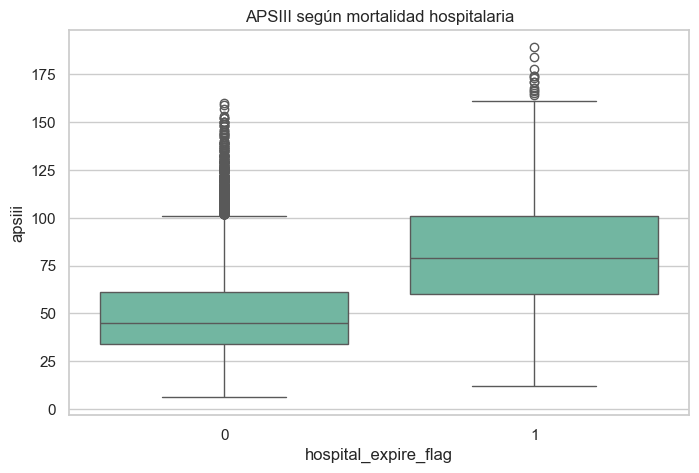

,count,mean,std,min,25%,50%,75%,max
hospital_expire_flag,,,,,,,,
0,20070.0,49.472496,21.477200,6.0,34.0,45.0,61.0,160.0
1,3636.0,80.995050,28.558114,12.0,60.0,79.0,101.0,189.0


In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='hospital_expire_flag', y='apsiii')
plt.title('APSIII según mortalidad hospitalaria')
plt.xlabel('hospital_expire_flag')
plt.ylabel('apsiii')
plt.show()

df.groupby('hospital_expire_flag')['apsiii'].describe()


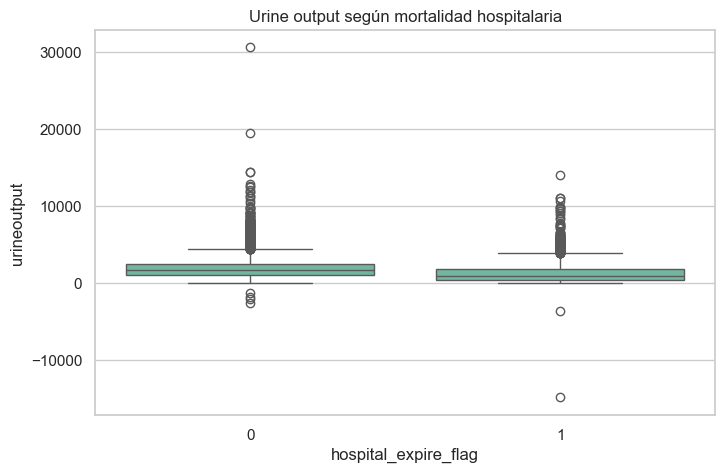

,count,mean,std,min,25%,50%,75%,max
hospital_expire_flag,,,,,,,,
0,20070.0,1873.137417,1233.170140,-2600.0,1050.0,1665.0,2420.000000,30595.0
1,3636.0,1259.140406,1299.370144,-14850.0,376.0,960.0,1778.963236,14090.0


In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='hospital_expire_flag', y='urineoutput')
plt.title('Urine output según mortalidad hospitalaria')
plt.xlabel('hospital_expire_flag')
plt.ylabel('urineoutput')
plt.show()

df.groupby('hospital_expire_flag')['urineoutput'].describe()


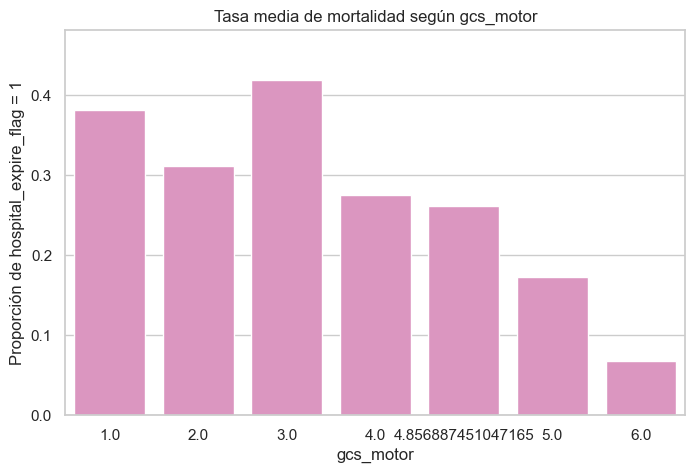

,gcs_motor,mortalidad_media
0,1.000000,0.381473
1,2.000000,0.312057
2,3.000000,0.418848
3,4.000000,0.275093
4,4.856887,0.261682
5,5.000000,0.172877
6,6.000000,0.067919


In [26]:
mortality_by_gcs_motor = (
    df.groupby('gcs_motor', dropna=False)['hospital_expire_flag']
      .mean()
      .reset_index(name='mortalidad_media')
      .sort_values('gcs_motor')
)

plt.figure(figsize=(8, 5))
sns.barplot(data=mortality_by_gcs_motor, x='gcs_motor', y='mortalidad_media', color=sns.color_palette()[3])
plt.title('Tasa media de mortalidad según gcs_motor')
plt.xlabel('gcs_motor')
plt.ylabel('Proporción de hospital_expire_flag = 1')
plt.ylim(0, mortality_by_gcs_motor['mortalidad_media'].max() * 1.15)
plt.show()

mortality_by_gcs_motor


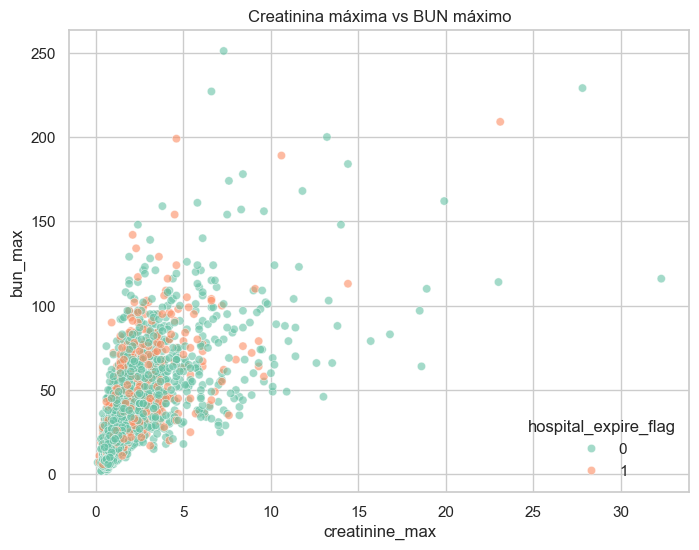

,creatinine_max,bun_max,hospital_expire_flag
creatinine_max,1.000000,0.769995,0.181213
bun_max,0.769995,1.000000,0.214402
hospital_expire_flag,0.181213,0.214402,1.000000


In [27]:
sample_df = df.sample(min(4000, len(df)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_df,
    x='creatinine_max',
    y='bun_max',
    hue='hospital_expire_flag',
    alpha=0.6
)
plt.title('Creatinina máxima vs BUN máximo')
plt.xlabel('creatinine_max')
plt.ylabel('bun_max')
plt.show()

df[['creatinine_max', 'bun_max', 'hospital_expire_flag']].corr(method='spearman')


## Conclusiones iniciales

- `apsiii` y `apsiii_prob` son las variables con mayor relación positiva con la mortalidad hospitalaria.
- Un peor estado neurológico (`gcs_motor`, `gcs_verbal`, `gcs_eyes`) se asocia con mayor mortalidad.
- Menor `urineoutput` y peores marcadores renales (`creatinine_*`, `bun_*`) también muestran una asociación clara con mortalidad.
- La base final no contiene fechas explícitas, pero sí variables temporales derivadas útiles para el EDA.

Este notebook sirve como punto de partida y se puede extender después con:

- comparación por subgrupos de edad o sexo;
- detección de outliers clínicamente plausibles;
- preparación para modelado predictivo.
